# Machine Learning Project — Car Price Analysis & FIFA Player Scouting

This project applies supervised learning to two real-world prediction problems and ends with a unified FIFA player scouting system.

**Main topics:** regression, classification, preprocessing, feature encoding, hyperparameter tuning, cross-validation, ensemble learning, model evaluation, and interactive prediction.

# Exploratory Data Analysis (EDA)

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,TargetEncoder
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,accuracy_score,classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

## How many rows and columns does the dataset have?

In [6]:
df = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\car_price.csv")
rows , cols = df.shape
print(f"rows = {rows}, columns = {cols}")

rows = 72435, columns = 10


In [7]:
df.head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


## Which features are numerical? Which are categorical?

In [9]:
df.dtypes

model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

## Are there any missing values? How many, and in which columns?

In [10]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

## What does the distribution of car prices look like?

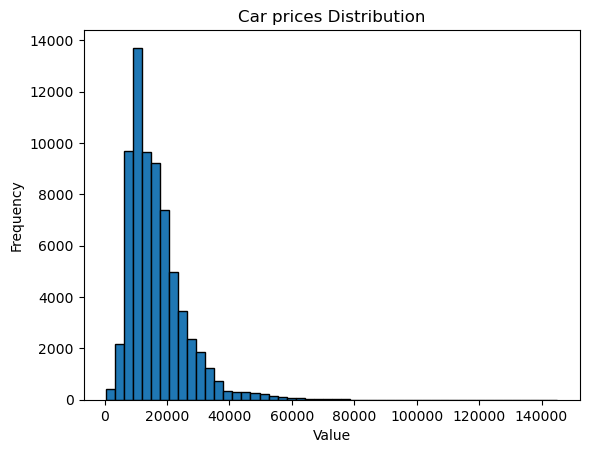

In [11]:
#shows histogram of the car prices using square root the number of rows
plt.hist(df["price"],bins=50,edgecolor='black')
plt.title('Car prices Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# Data Preprocessing

In [12]:
df = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\car_price.csv")

### Split the data into training and test sets 80/20 split.

In [13]:
# remove missing target values
df = df.dropna(subset=['price'])
df = df.drop_duplicates()
df['year'] = df['year'] - 2010

# splits data to 80/20
train_data, test_data = train_test_split(df, test_size=0.2, random_state=1)

#resets the index for both dataset
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

### Detect and handle outliers — use boxplots or the IQR method.


In [14]:
#taking only the numeric columns
cols = train_data.select_dtypes(include=[np.number]).columns

# Drop 'price' from the list of columns to clip
if 'price' in cols:
    cols = cols.drop('price')
#looping for each column calculating iqr to remove the outliers
for col in cols:
    q1 = train_data[col].quantile(0.25)
    q3 = train_data[col].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers_count = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col}: {outliers_count} outliers.")

    #removes the outliers by replacing the old dataframe
    train_data[col] = train_data[col].clip(lower=lower, upper=upper)

train_data = train_data.reset_index(drop=True)

year: 931 outliers.
mileage: 2053 outliers.
tax: 189 outliers.
mpg: 805 outliers.
engineSize: 240 outliers.


### Handle missing values —drop rows, fill with mean/mode, or another strategy. Justify your choice.

- KNN Imputer will improve the accuracy by using the similar objects to predict the missing values.

In [15]:
#separating the numeric columns from the original dataset
numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()

if 'price' in numeric_cols:
    numeric_cols.remove('price')
#computing the missing values by the nearest 3 rows
knn = KNNImputer(n_neighbors=7)

# apply fit on the training first to avoid data leakage
train_data[numeric_cols] = knn.fit_transform(train_data[numeric_cols])
test_data[numeric_cols]  = knn.transform(test_data[numeric_cols])

# handling the missing values in the categorical columns using the mode
mode = SimpleImputer(strategy='most_frequent')

categorical_cols = [ 'model', 'Make','transmission','fuelType']
# apply fit on the training first to avoid data leakage
train_data[categorical_cols] = mode.fit_transform(train_data[categorical_cols])
test_data[categorical_cols] = mode.transform(test_data[categorical_cols])

### Encode categorical columns — use Label Encoding or One-Hot Encoding. Explain which and why.

-  One-Hot Encoding is better because in knn and liner Regression will think the higher the label the futher the traget which not true

In [16]:
# One-Hot Encode everything execpt model
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform='pandas')
encoded_train = ohe.fit_transform(train_data[categorical_cols[1:]])
encoded_test = ohe.transform(test_data[categorical_cols[1:]])
# TE will group the models and calculates the mean of each model and replaces it with the mean
te = TargetEncoder(target_type='continuous').set_output(transform='pandas')

model_train = te.fit_transform(train_data[['model']], train_data["price"])
model_test = te.transform(test_data[['model']])

# Merging the new encoded data to the DF with dropping the old categorical columns
train_data = pd.concat([train_data.drop(columns=categorical_cols), model_train, encoded_train], axis=1)
test_data = pd.concat([test_data.drop(columns=categorical_cols), model_test, encoded_test], axis=1)

### Scale numerical features — important for KNN. Use StandardScaler or MinMaxScaler.

In [17]:
#the range of the scaled values
scale = MinMaxScaler(feature_range=(0,1))

# not scaled data
train_data_raw = train_data
test_data_raw = test_data
# separating the target from the features
train_target = train_data["price"]
train_data = train_data.drop(columns=["price"])

test_target = test_data["price"]
test_data = test_data.drop(columns=["price"])
#columns names
cols = train_data.columns

#scaled data
scale_train = scale.fit_transform(train_data)
scale_test = scale.transform(test_data)

#merging the columns names with the data
train_data = pd.DataFrame(scale_train,columns=cols)
test_data = pd.DataFrame(scale_test,columns=cols)
train_data

,year,mileage,tax,mpg,engineSize,model,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,Make_vw,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.882353,0.084879,0.456693,0.375000,0.468750,0.220559,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.764706,0.039305,0.472441,0.727349,0.312500,0.163444,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.647059,0.233724,0.456693,0.625000,0.312500,0.162883,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.647059,0.253504,0.456693,0.375000,0.625000,0.231151,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.882353,0.170649,0.456693,0.239094,0.625000,0.325045,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54764,0.882353,0.042432,0.456693,0.482383,0.312500,0.094452,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54765,0.882353,0.223056,0.456693,0.559564,0.312500,0.162065,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54766,0.529412,0.307907,0.393701,0.482383,0.459821,0.162065,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54767,0.647059,0.401572,0.740157,0.289430,0.937500,0.451520,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [18]:
# assign the data to be ready for modeling
X_train = train_data
y_train = train_target.reset_index(drop=True)

X_test = test_data
y_test = test_target.reset_index(drop=True)

## Which features seem most related to price?

- the model is the most related to the price (0.76).
- year (0.54).
- mileage (-0.44).
- tax (0.36).
- mpg (-0.53).
- engine size (0.60).
- transmission_Manual (-0.50)

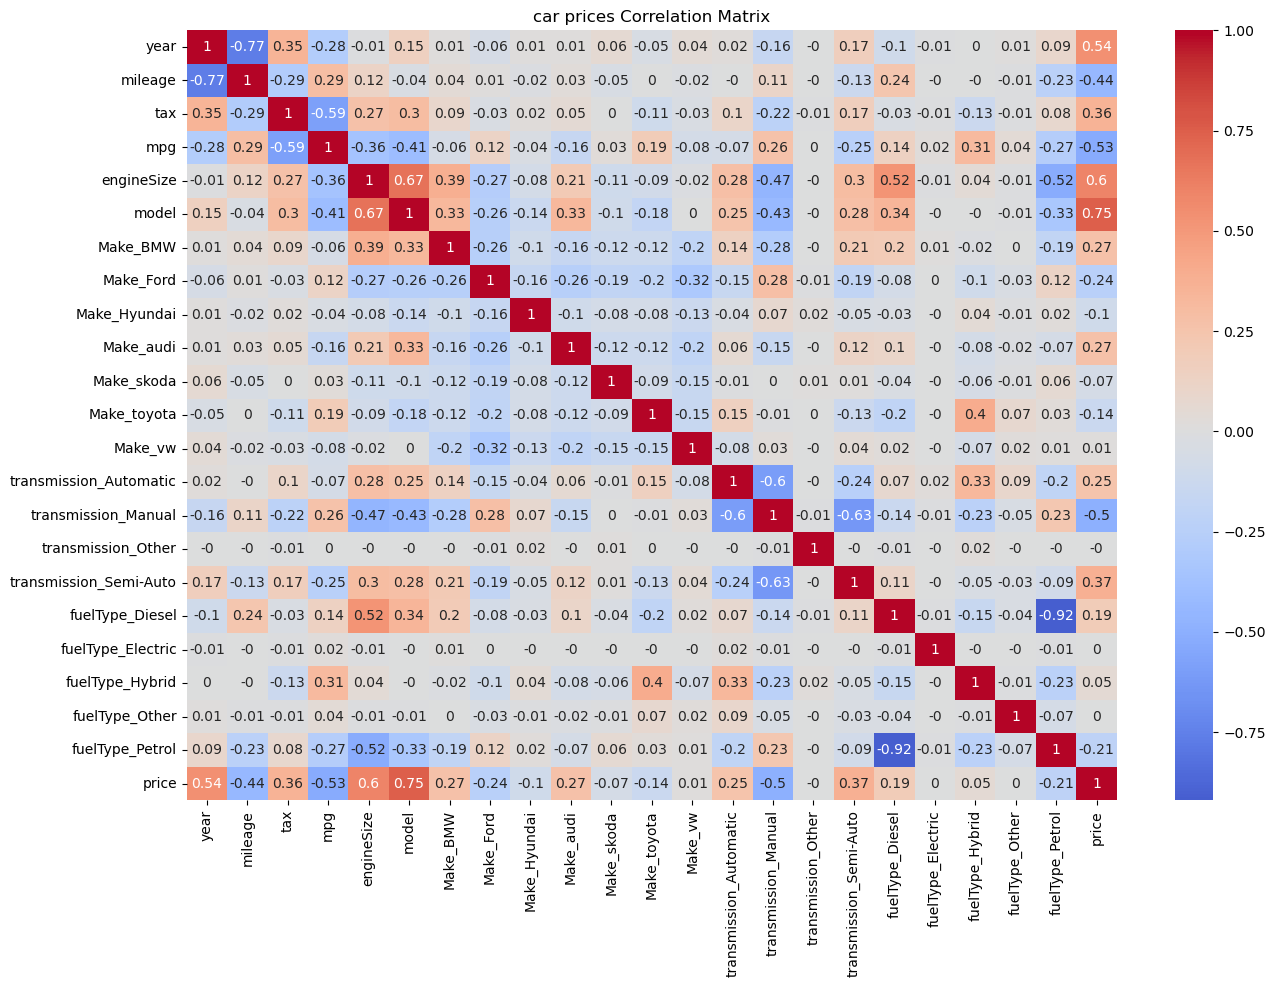

The feature with the strongest correlation to Price is: model


In [19]:
# computing the correlation rounded by 2
final_train = pd.concat([train_data,train_target], axis=1)
corr = final_train.corr().round(2)

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("car prices Correlation Matrix")
plt.show()

top_feature = corr['price'].drop('price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

# **Modeling and Evaluation**

# **Linear Regression**

In [20]:
# --- Simple Regression ---
simple_model = LinearRegression()
simple_model.fit(X_train[[top_feature]], y_train)
y_pred_simple = simple_model.predict(X_test[[top_feature]])

In [21]:
print(simple_model.intercept_, simple_model.coef_)

1205.3641244133723 [70181.58977487]


In [22]:
y_pred_simple

array([13176.85155739, 21919.98697844, 17559.30088627, ...,
       16003.45271502, 12620.07767036, 22697.1840931 ], shape=(13693,))

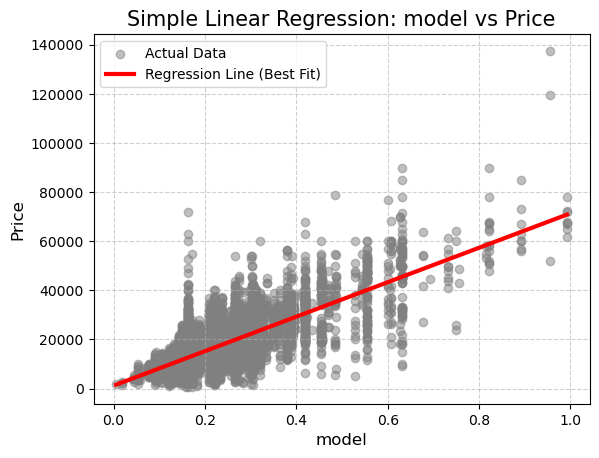

Model Equation: Price = (70181.59 * model) + 1205.36


In [23]:
feature_name = top_feature


# Plot the actual test data points
plt.scatter(X_test[[feature_name]], y_test, color='gray', alpha=0.5, label='Actual Data')

# Plot the regression line using model predictions
# We sort the values to ensure the line is drawn smoothly from left to right
X_range = np.linspace(X_test[feature_name].min(), X_test[feature_name].max(), 100).reshape(-1, 1)
y_range_pred = simple_model.predict(pd.DataFrame(X_range, columns=[feature_name]))

plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line (Best Fit)')

# Formatting
plt.title(f'Simple Linear Regression: {feature_name} vs Price', fontsize=15)
plt.xlabel(feature_name, fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print the model equation: Price = (Slope * Feature) + Intercept
print(f"Model Equation: Price = ({simple_model.coef_[0]:.2f} * {feature_name}) + {simple_model.intercept_:.2f}")

In [24]:
# --- Multiple Regression ---
multi_model  = LinearRegression()
multi_model .fit(X_train , y_train)
y_pred_multi = multi_model .predict(X_test)

In [25]:
print(multi_model.intercept_ ,multi_model.coef_)

3361.6838505333726 [12615.35880697 -7169.05546472 -5718.17933858 -9034.85274477
 13957.53796487 40000.2843641    499.50664023   260.33813137
  -966.30969983  1410.54212395  -480.79939491  -681.62104144
   -41.65675936   630.26796665  -520.16787258 -1440.12268342
  1330.02258935 -2480.93431809  3763.46602061  1662.19168431
  -345.27794282 -2599.44544401]


In [26]:
y_pred_multi

array([ 6063.36975518, 25551.71018547, 19995.21816524, ...,
       10815.33907476, 10103.17716235, 20893.49413321], shape=(13693,))

In [27]:
print(f"Simple Linear Regression (Feature: {top_feature})")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.4f}")
print("-" * 30)
print("Multiple Linear Regression (All Features)")
print(f"R2 Score: {r2_score(y_test, y_pred_multi):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")
mae = mean_absolute_error(y_test, y_pred_multi)
print("MAE:", mae)

Simple Linear Regression (Feature: model)
R2 Score: 0.5842
------------------------------
Multiple Linear Regression (All Features)
R2 Score: 0.8150
Root Mean Squared Error: 3948.26
MAE: 2469.1739880217665


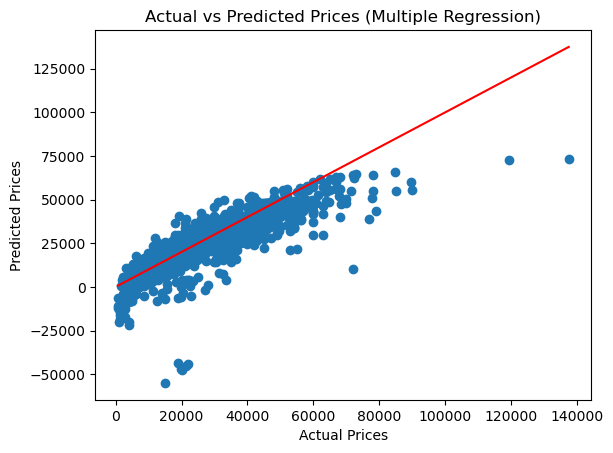

In [28]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Multiple Regression)")

# optional: perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.show()

## Testing on one point

In [29]:
sample = X_test.iloc[[0]]
pred = multi_model.predict(sample)

actual = y_test.iloc[0]

print("Predicted:", pred)
print("Actual:", actual)
print("Error:", abs(actual - pred))

Predicted: [6063.36975518]
Actual: 7141.0
Error: [1077.63024482]


# **KNN Classification**

**Classification Target**

In [30]:
# Price categories were created using quantile-based thresholds (33% and 66%)
# to ensure balanced classes and adaption to the data (data-driven)

# compute thresholds from TRAIN prices only to avoid data leakage
q1 = train_target.quantile(0.33)
q2 = train_target.quantile(0.66)

def price_category(price):
    if price <= q1:
        return "Cheap"
    elif price <= q2:
        return "Moderate"
    else:
        return "Expensive"

# classification targets
y_train_cls = train_target.apply(price_category)
y_test_cls = test_target.apply(price_category)

In [31]:
print("Price Category Thresholds:")
print(f"q1: {q1:.2f}")
print(f"q2: {q2:.2f}")

Price Category Thresholds:
q1: 11485.00
q2: 17991.00


**how many cars fall into each category after splitting**

In [32]:
print("\nTraining Set Category Distribution:")
print(y_train_cls.value_counts())


Training Set Category Distribution:
price
Expensive    18621
Cheap        18079
Moderate     18069
Name: count, dtype: int64


In [33]:
print("\nTest Set Category Distribution:")
print(y_test_cls.value_counts())


Test Set Category Distribution:
price
Expensive    4617
Cheap        4608
Moderate     4468
Name: count, dtype: int64


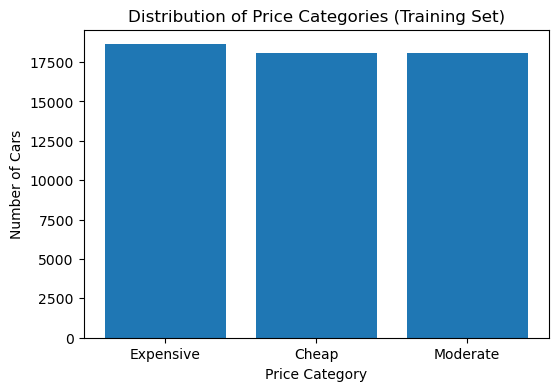

In [34]:
# Count values
counts = y_train_cls.value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.title("Distribution of Price Categories (Training Set)")
plt.show()

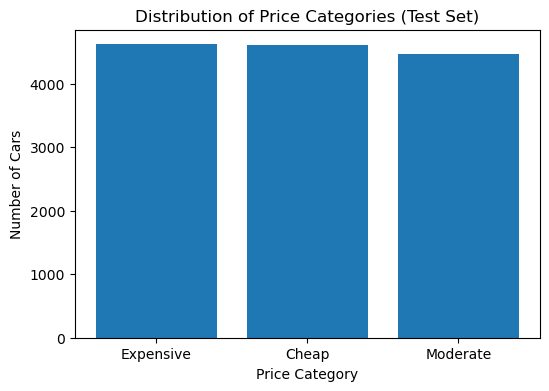

In [35]:
counts_test = y_test_cls.value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts_test.index, counts_test.values)

plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.title("Distribution of Price Categories (Test Set)")
plt.show()

**KNN with Grid Search and kfold to find the best combination of parameters**

In [36]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,               # 5-Fold Cross Validation
    scoring='accuracy'
)

grid.fit(train_data, y_train_cls)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


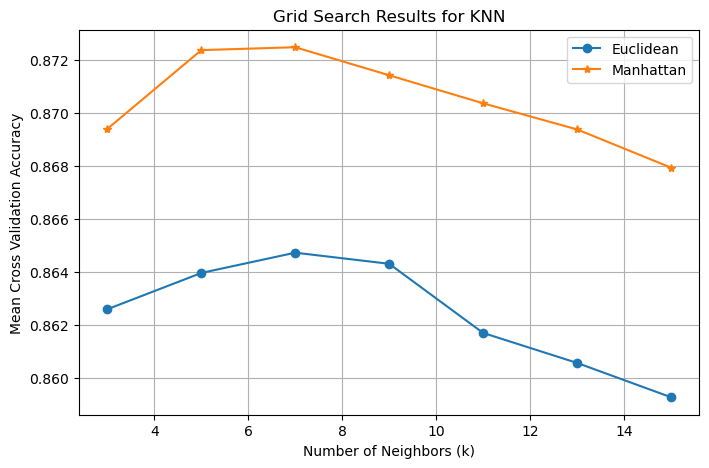

In [37]:
# Convert grid search results to DataFrame
results = pd.DataFrame(grid.cv_results_)

# Separate metrics
euclidean = results[results['param_metric'] == 'euclidean']
manhattan = results[results['param_metric'] == 'manhattan']

plt.figure(figsize=(8, 5))

plt.plot(
    euclidean['param_n_neighbors'],
    euclidean['mean_test_score'],
    marker='o',
    label='Euclidean'
)

plt.plot(
    manhattan['param_n_neighbors'],
    manhattan['mean_test_score'],
    marker='*',
    label='Manhattan'
)

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross Validation Accuracy')
plt.title('Grid Search Results for KNN')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best Cross Validation Accuracy: 0.8724826832846189


**Predictions on Test Set**

In [39]:
best_knn = grid.best_estimator_
y_pred = best_knn.predict(test_data)

**Evaluation Metrics**

In [40]:
# Accuracy, Precision, Recall, F1

print(classification_report(
    y_test_cls,
    y_pred,
    target_names=["Cheap", "Moderate", "Expensive"]
))

              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.90      4608
    Moderate       0.91      0.91      0.91      4617
   Expensive       0.81      0.82      0.82      4468

    accuracy                           0.88     13693
   macro avg       0.88      0.88      0.88     13693
weighted avg       0.88      0.88      0.88     13693



**Confusion Matrix**

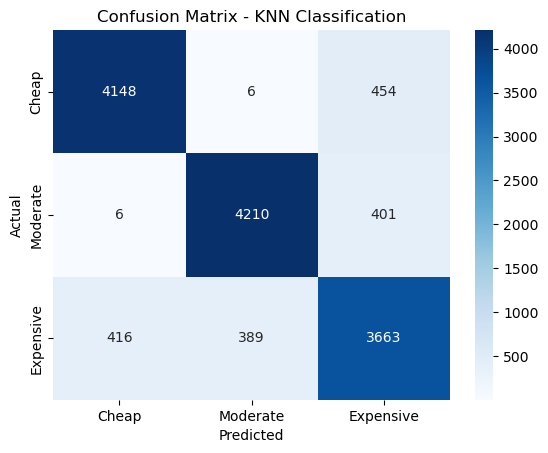

In [41]:
cm = confusion_matrix(y_test_cls, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["Cheap", "Moderate", "Expensive"],
    yticklabels=["Cheap", "Moderate", "Expensive"],
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Classification")
plt.show()

While the model is relatively good at classifying Moderate and Cheap cars, it is less effective at distinguishing the Expensive category. This suggests that the chosen price thresholds or the current feature set may not fully capture the unique characteristics of high-end vehicles

# Analysis and Discussion

***1) Model Comparison***


1.
Simple Linear Regression model achieved an R² score = 0.5842 which indicates that using a single feature is not sufficient to explain the variance in car prices and results in lower predictive performance

Multiple Linear Regression model achieved an R² score = 0.8148 (RMSE) = 4053.73 and (MAE) = 2508.59 This indicates that the model can explain about 81% of the variance in car prices with lower prediction error compared to simple regression

On the other hand, the KNN Classification model achieved an accuracy = 0.87, that mean correctly classified 87% of the cars into their respective price categories

In this context "better" depends on the objective:

For regression, better means lower error (RMSE, MAE) and higher R²
For classification better means higher accuracy and balanced performance across classes

Overall:

Multiple Linear Regression performed better than Simple Linear Regression because it uses all features and achieved higher R² with lower error
 while KNN model performed better in terms of classification accuracy
Linear Regression provides more detailed predictions  while KNN simplifies the task into categories with higher accuracy

2.
Classification is easier than regression on this dataset
 because regression requires predicting the exact car price which is a continuous value This makes the problem more complex and sensitive to small changes in the data, noise, and outliers.

classification simplifies the problem by converting the continuous price values into discrete categories (Cheap, Moderate, Expensive) This reduces the complexity of the prediction task and allows the model to focus on general patterns instead of exact values

In this dataset classification achieved relatively high accuracy (0.87) which shows that grouping prices into categories makes the learning task easier for the model
regression models showed different performance:

-Simple Linear Regression (R² = 0.5842) performed poorly because it depends on only one feature

-Multiple Linear Regression (R² = 0.8148) performed better but still requires predicting exact values

This confirms that classification is easier than regression as it reduces the prediction difficulty compared to estimating exact prices



3.

Yes converting price into categories loses important information
This is because the original price is a continuous value where small differences between prices can be meaningful (for example, 15000 and 17000) When we convert prices into categories such as Cheap, Moderate, and Expensive we group different values into the same class which removes these differences
this make models like Linear Regression (simple and multiple) can capture detailed variations in price while classification models lose this level of precision
However this simplification makes the problem easier to solve and help models like KNN achieve higher accuracy even though some detailed information is lost





**2)  Sensitivity Analysis**

In [42]:
X_train_drop = X_train.drop(columns=[top_feature])
X_test_drop = X_test.drop(columns=[top_feature])

model = LinearRegression()
model.fit(X_train_drop, y_train)
y_pred = model.predict(X_test_drop)

print("R2 after removing feature:", r2_score(y_test, y_pred))

R2 after removing feature: 0.694017019838095


In [43]:
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train_drop, y_train_cls)
y_pred_knn = knn.predict(X_test_drop)

print("Accuracy after removing feature:", accuracy_score(y_test_cls, y_pred_knn))

Accuracy after removing feature: 0.8634338713211129




1.
   Removing the most correlated feature leads to a noticeable drop in performance for the regression model

For the Multiple Linear Regression model the R² score decreased from 0.8081 to 0.6904 after removing the most correlated feature This shows a significant reduction in performance meaning the model become less able to explain the variance in car prices without this important feature

This confirms that the model strongly depends on highly correlated features to make accurate predictions

For the KNN classification model the accuracy decreased slightly from about 0.87 to 0.859 after removing the feature This indicates that KNN is less sensitive to the removal of a single feature likely because it uses multiple features and distance-based relationships
 Conclusion

Regression model is highly sensitive to removing important features
KNN classification is more stable, with only minor changes in performance




In [44]:
X_train_raw = train_data_raw.drop(columns=["price"]).copy()
X_test_raw = test_data_raw.drop(columns=["price"]).copy()

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train_raw, y_train_cls)
y_pred_raw = knn.predict(X_test_raw)

print("Accuracy WITH scaling:", accuracy_score(y_test_cls, best_knn.predict(X_test)))
print("Accuracy WITHOUT scaling:", accuracy_score(y_test_cls, y_pred_raw))

Accuracy WITH scaling: 0.877893814357701
Accuracy WITHOUT scaling: 0.7641130504637406



2.
Running the KNN model without feature scaling shows a noticeable difference in performance. The accuracy with scaling was approximately 0.87while the accuracy without scaling dropped to around 0.757 This indicates that feature scaling had a clear positive impact on the model’s performance

The main reason behind this difference is that KNN is a distance-based algorithm meaning it is highly sensitive to the scale of features When features are not scaled variables with larger numerical ranges dominate the distance calculation which leads to biased nearest-neighbor selection and reduces model accuracy

After applying MinMaxScaler all features were brought to the same range (0 to 1) which ensured that each feature contributed equally to the distance computation. This improved the quality of neighbor selection and resulted in higher classification accuracy

Conclusion Feature scaling  improved KNN performance in this dataset by ensuring fair distance calculations across features with different ranges leading to a more accurate and reliable model



In [45]:
q1_new = train_target.quantile(0.40)
q2_new = train_target.quantile(0.60)
def price_category_new(price):
    if price <= q1_new:
        return "Cheap"
    elif price <= q2_new:
        return "Moderate"
    else:
        return "Expensive"

y_train_cls_new = train_target.apply(price_category_new)
y_test_cls_new = test_target.apply(price_category_new)

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9)
knn.fit(X_train, y_train_cls_new)
y_pred_new = knn.predict(X_test)

print("Accuracy with new thresholds:", accuracy_score(y_test_cls_new, y_pred_new))

Accuracy with new thresholds: 0.8692032425326809




3.
After modifying the threshold values for splitting the car prices into categories (using 40% and 60% instead of the original 33% and 66%) the KNN model was retrained and evaluated

The accuracy decreased slightly changed from 0.87 to 0.8665

This indicates that changing the thresholds has a minor impact on model performance but the change is not significant The small drop in accuracy is likely due to a less optimal class distribution compared to the original split

 Conclusion:

KNN performance is relatively stable when changing price category thresholds, with only slight variations in accuracy (0.87 to 0.866) showing that the model is not highly sensitive to these changes



# Visualization

**Price distribution histogram (from EDA)**

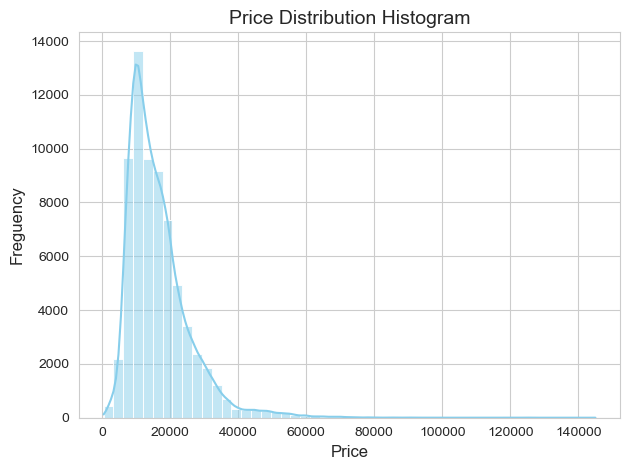

In [46]:
sns.set_style("whitegrid")
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("Price Distribution Histogram", fontsize=14)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Freguency", fontsize=12)
plt.tight_layout()
plt.show()

**Correlation heatmap (from EDA)**

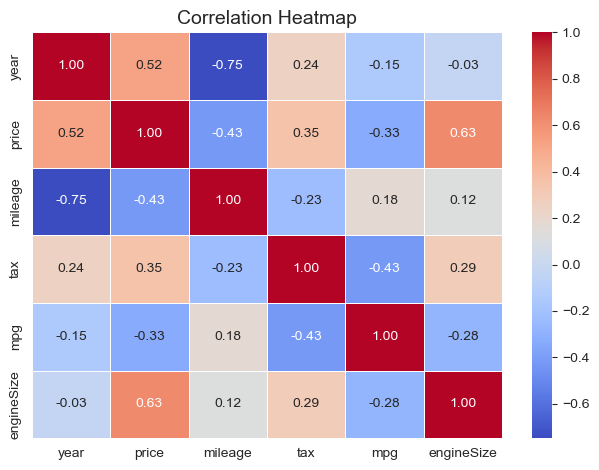

In [47]:
sns.set_style("white")
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

**Predicted vs. Actual scatter plot (Regression)**

**Single Regression (Actual vs Predicted)**

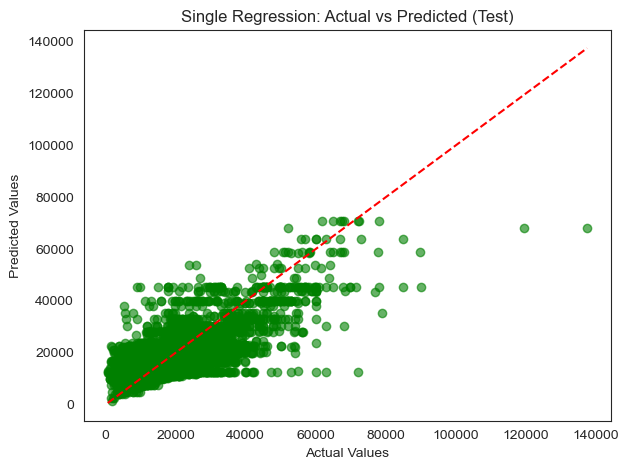

In [48]:
plt.scatter(y_test,y_pred_simple,alpha=0.6,color='green')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linestyle='--')
plt.title("Single Regression: Actual vs Predicted (Test)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

**Multiple Regression (Actual vs Predicted)**

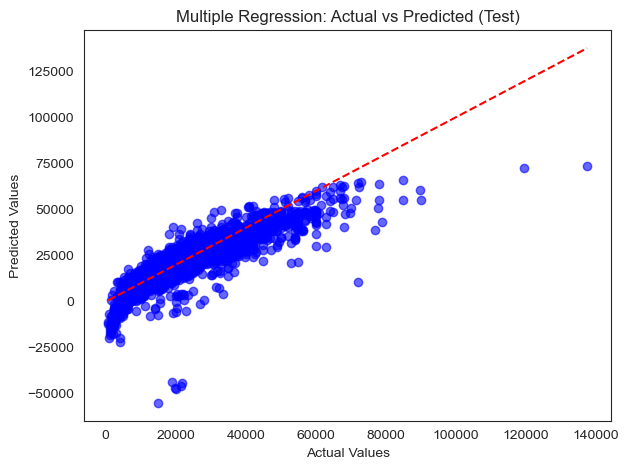

In [49]:
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='blue')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linestyle='--')
plt.title("Multiple Regression: Actual vs Predicted (Test)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

**Confusion Matrix heatmap (Classification)**

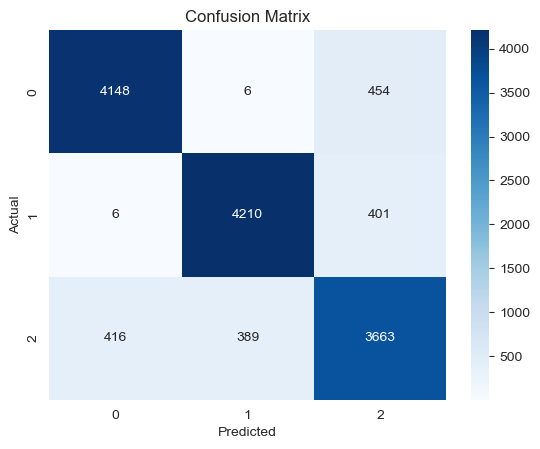

In [50]:

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Two additional meaningful plots .**

**Plot 1: Price vs Mileage**

**This plot shows the relationship between mileage and price.
It helps determine whether cars with higher mileage tend to have lower prices. A scatter plot is used to visualize the relationship between mileage and price. It helps identify trends, correlations, and outliers between the two numerical variables. The plot may reveal a negative correlation, where higher mileage is associated with lower prices**

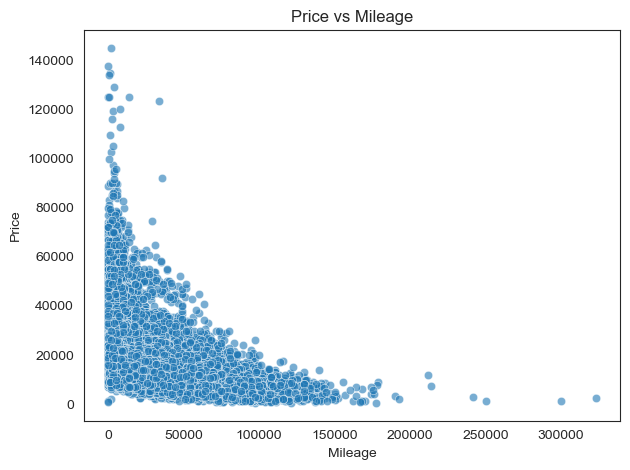

In [51]:
sns.scatterplot(x=df['mileage'], y=df['price'], alpha=0.6)
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

**Plot 2: Price by Fuel Type**

**This plot compares the distribution of prices across different fuel types, helping identify which fuel types are associated with higher or lower prices. A box plot is used to visualize the distribution of prices across different fuel types, including median, variability, and outliers**

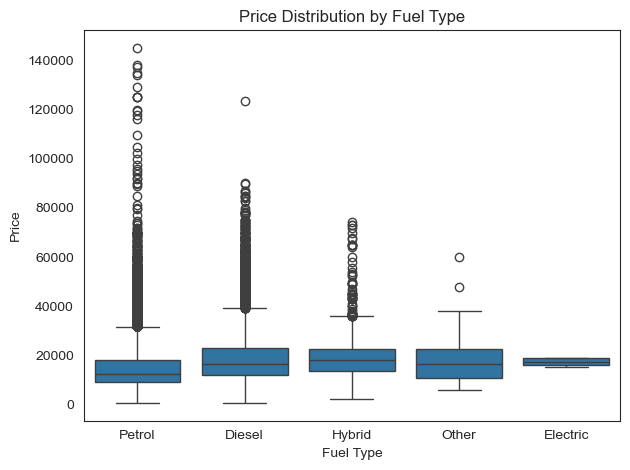

In [52]:
sns.boxplot(x=df['fuelType'], y=df['price'])
plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,TargetEncoder,StandardScaler, PolynomialFeatures
from sklearn.impute import KNNImputer,SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import StackingRegressor, StackingClassifier, VotingClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score,classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, StratifiedKFold, learning_curve

# Exploratory Data Analysis (EDA)

In [54]:
# fifa = "/content/drive/MyDrive/Machine Learning Assignment 2/Fifa.csv"

In [57]:
df = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\Fifa.csv")

In [58]:
# df = pd.read_csv("/content/Fifa.csv")

## How many rows and columns does the dataset have?

In [59]:
rows , cols = df.shape
print(f"rows = {rows}, columns = {cols}")

rows = 19667, columns = 9


In [60]:
df.head(20)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
5,Abdel Rahman Boudi,Egypt,RB,27,65,67,Ittihad Alexandria,0.450,1610
6,Karim El Deeb,Egypt,CM,33,67,67,Ittihad Alexandria,0.300,1680
7,Mohamed Tony,Egypt,CDM,29,66,67,Ittihad Alexandria,0.380,1655
8,Nour Alaa El Din,Egypt,CAM,24,64,70,Ittihad Alexandria,0.600,1590
9,Fady Farid,Egypt,ST,28,67,68,Ittihad Alexandria,0.550,1670


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [62]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [63]:
df.dtypes

Name                  object
Country               object
Position              object
Age                    int64
Overall_Rating         int64
Future Potential       int64
Team                  object
Value Per M$         float64
Total_Stats Score      int64
dtype: object

## Are there any missing values? How many, and in which columns?

In [64]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

## Distribution of "Value Per M$"

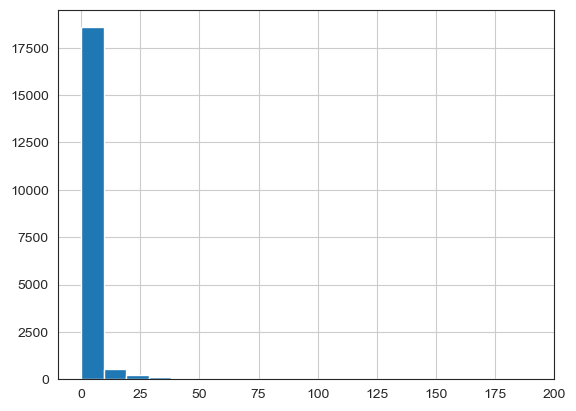

In [65]:
df['Value Per M$'].hist(bins=20)
plt.show()

In [66]:
# compute the skewness
df["Value Per M$"].skew()

np.float64(7.983215201865151)

In [67]:
df.corr(numeric_only=True)["Value Per M$"].sort_values(ascending=False)

Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64

In [68]:
df.groupby("Position")["Overall_Rating"].mean()

Position
CAM    63.679709
CB     63.544448
CDM    64.234168
CF     66.042857
CM     62.511767
GK     60.987288
LB     63.276794
LM     64.172009
LW     64.345979
LWB    64.043333
RB     62.863636
RF     75.000000
RM     63.907731
RW     63.718529
RWB    64.063973
ST     63.087505
SW     75.000000
Name: Overall_Rating, dtype: float64

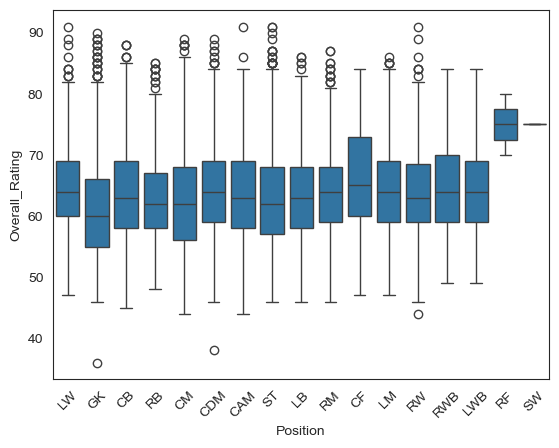

In [69]:
sns.boxplot(x="Position", y="Overall_Rating", data=df)
plt.xticks(rotation=45)
plt.show()

# Data Preprocessing

In [70]:
# df = pd.read_csv(fifa)
df = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\Fifa.csv")

In [71]:
df.duplicated().sum()

np.int64(0)

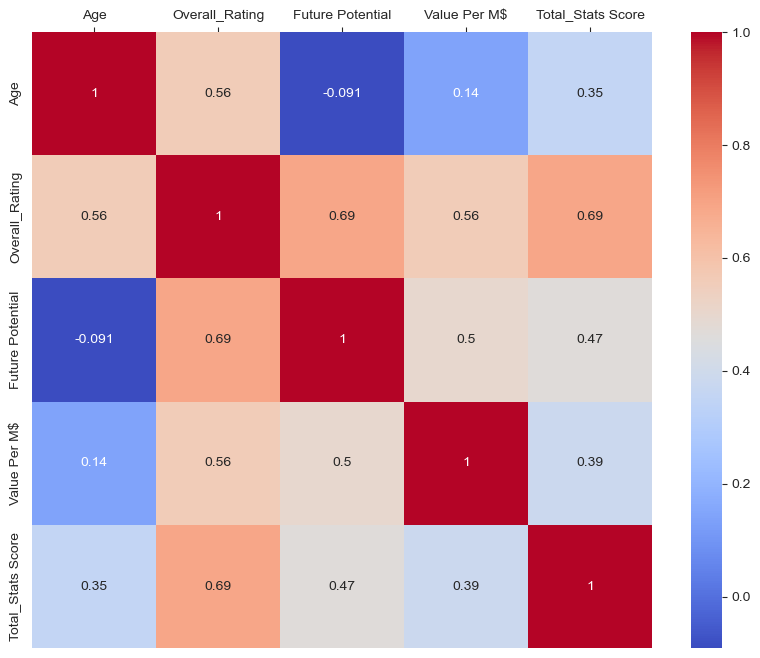

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.gca().xaxis.tick_top()
plt.show()

## Split the dataset into Train and Test sets (80/20) before applying any preprocessing step.

In [74]:
X = df.drop("Value Per M$", axis=1)
y = df["Value Per M$"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (15733, 8)  |  Test: (3934, 8)


## Detect and handle outliers

In [75]:
y_train

10156     1.300
10392     0.300
8124      3.900
13075     0.675
19445     1.300
          ...  
11284     0.475
11964     1.000
5390      0.700
860      27.500
15795     1.200
Name: Value Per M$, Length: 15733, dtype: float64

In [76]:
# outliers in x_train
#taking only the numeric columns
cols = X_train.select_dtypes(include=[np.number]).columns

print(cols)
#looping for each column calculating iqr to remove the outliers
for col in cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers_count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"{col}: {outliers_count} outliers.")

    #removes the outliers by replacing the old dataframe
    # X_train[col] = X_train[col].clip(lower=lower, upper=upper)

train_data = X_train.reset_index(drop=True)

Index(['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score'], dtype='object')
Age: 129 outliers.
Overall_Rating: 111 outliers.
Future Potential: 94 outliers.
Total_Stats Score: 666 outliers.


In [77]:
# don't try runing this line I told you !!!
# y_train = y_train.clip(lower=lower, upper=upper)

In [78]:
X_train

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Mizuki Arai,Japan,LW,25,67,70,Gil Vicente,1689
10392,Juan Felipe Moreno,Colombia,ST,19,55,68,Midtjylland,1351
8124,Fábio Alexandre Silva Coentrão,Portugal,RW,32,75,75,Rio Ave,2049
13075,Luís Fellipe Rodrigues Mota,Portugal,ST,17,61,71,Belenenses,1448
19445,Juan Acosta,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...,...
11284,Maikel Reyes,Ecuador,CM,19,59,70,Delfin,1680
11964,Visar Musliu,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Yuki Ohashi,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Wilfred Ndidi,Nigeria,CM,25,81,82,Leicester City,2042


IQR outliers in Value Per M$: 1897


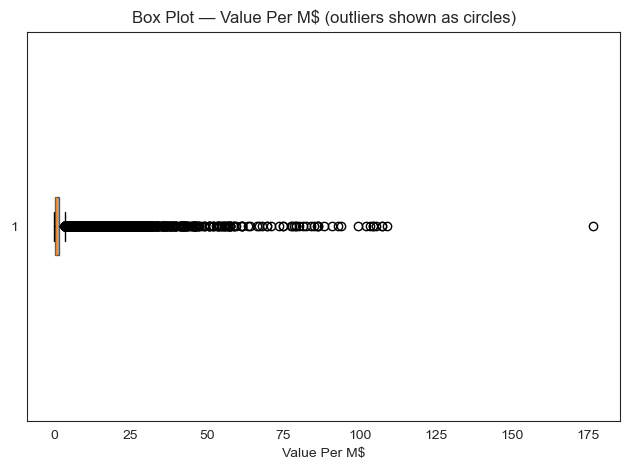

In [79]:
# outliers for y_train
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = y_train[(y_train <= lower) | (y_train >= upper)]
print(f'IQR outliers in Value Per M$: {len(outliers_iqr)}')

# Visualise with box plot
plt.boxplot(y_train, vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot — Value Per M$ (outliers shown as circles)')
plt.xlabel('Value Per M$')
plt.tight_layout()
plt.show()

## Handle and Encode categorical data

In [80]:
X_train = X_train.drop("Name", axis=1)
X_test = X_test.drop("Name", axis=1)

In [81]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [82]:
#for omar
import pandas as pd
from sklearn.preprocessing import TargetEncoder

# 3. Target Encoding (Fit on Train, Transform Both)
te = TargetEncoder(smooth="auto")
X_train_te = pd.DataFrame(te.fit_transform(X_train[['Team', 'Country']], y_train),
                          columns=['Team', 'Country'], index=X_train.index)
X_test_te = pd.DataFrame(te.transform(X_test[['Team', 'Country']]),
                         columns=['Team', 'Country'], index=X_test.index)

# 4. One-Hot Encoding
X_train_ohe = pd.get_dummies(X_train['Position'], prefix='Pos', dtype=int)
X_test_ohe = pd.get_dummies(X_test['Position'], prefix='Pos', dtype=int).reindex(columns=X_train_ohe.columns, fill_value=0)

# 5. Final Concat: Combine Numerical + TE + OHE
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
X_train_te_ohe_enc = pd.concat([X_train[num_cols], X_train_te, X_train_ohe], axis=1)
X_test_te_ohe_enc = pd.concat([X_test[num_cols], X_test_te, X_test_ohe], axis=1)

In [83]:
X_train_te_ohe_enc

,Age,Overall_Rating,Future Potential,Total_Stats Score,Team,Country,Pos_CAM,Pos_CB,Pos_CDM,Pos_CF,...,Pos_LM,Pos_LW,Pos_LWB,Pos_RB,Pos_RF,Pos_RM,Pos_RW,Pos_RWB,Pos_ST,Pos_SW
10156,25,67,70,1689,3.010837,1.289341,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
10392,19,55,68,1351,1.962390,2.212298,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8124,32,75,75,2049,1.403627,6.521756,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
13075,17,61,71,1448,1.090335,5.820093,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
19445,28,69,69,1748,0.998136,2.265386,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.584092,1.334497,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11964,27,67,68,1557,0.767458,3.289558,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5390,24,63,67,1568,0.423112,1.470786,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
860,25,81,82,2042,6.513454,3.782993,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [85]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,25,67,70,1689,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10392,19,55,68,1351,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8124,32,75,75,2049,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13075,17,61,71,1448,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19445,28,69,69,1748,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11964,27,67,68,1557,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5390,24,63,67,1568,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
860,25,81,82,2042,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [86]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Algeria,Country_Andorra,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zhejiang,Team_Zulte-Waregem,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_Śląsk Wrocław
15659,34,68,68,1708,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1350,31,82,82,1992,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4871,22,59,65,1540,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16532,23,68,73,1830,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
385,27,86,86,2250,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,32,78,78,2071,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17406,20,56,70,1470,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5963,26,74,75,1970,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
14024,19,62,75,1606,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [88]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
15659,34,68,68,1708,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
1350,31,82,82,1992,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
4871,22,59,65,1540,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
16532,23,68,73,1830,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
385,27,86,86,2250,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,32,78,78,2071,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
17406,20,56,70,1470,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False
5963,26,74,75,1970,0,False,False,True,False,False,...,False,False,False,0,False,False,False,False,0,False
14024,19,62,75,1606,0,False,False,False,False,False,...,False,False,False,0,False,False,False,False,0,False


## Scale numerical features

In [89]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns


scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train_te_ohe_enc[num_cols] = scaler.fit_transform(X_train_te_ohe_enc[num_cols])
X_test_te_ohe_enc[num_cols] = scaler.transform(X_test_te_ohe_enc[num_cols])

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [90]:
X_train_te_ohe_enc

,Age,Overall_Rating,Future Potential,Total_Stats Score,Team,Country,Pos_CAM,Pos_CB,Pos_CDM,Pos_CF,...,Pos_LM,Pos_LW,Pos_LWB,Pos_RB,Pos_RF,Pos_RM,Pos_RW,Pos_RWB,Pos_ST,Pos_SW
10156,0.427468,0.483743,-0.102151,0.547828,3.010837,1.289341,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
10392,-0.852089,-1.059077,-0.410505,-0.643544,1.962390,2.212298,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8124,1.920283,1.512290,0.668734,1.816744,1.403627,6.521756,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
13075,-1.278607,-0.287667,0.052026,-0.301641,1.090335,5.820093,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
19445,1.067246,0.740880,-0.256328,0.755789,0.998136,2.265386,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,-0.544804,-0.102151,0.516105,0.584092,1.334497,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11964,0.853986,0.483743,-0.410505,0.082558,0.767458,3.289558,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5390,0.214208,-0.030530,-0.564682,0.121331,0.423112,1.470786,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
860,0.427468,2.283700,1.747973,1.792070,6.513454,3.782993,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [91]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,0.427468,0.483743,-0.102151,0.547828,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10392,-0.852089,-1.059077,-0.410505,-0.643544,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8124,1.920283,1.512290,0.668734,1.816744,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13075,-1.278607,-0.287667,0.052026,-0.301641,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19445,1.067246,0.740880,-0.256328,0.755789,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,-0.544804,-0.102151,0.516105,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11964,0.853986,0.483743,-0.410505,0.082558,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5390,0.214208,-0.030530,-0.564682,0.121331,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
860,0.427468,2.283700,1.747973,1.792070,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# **linear Regression**

## baseline Linear Regression model

In [92]:
# Model
baseline_reg_model = LinearRegression()
baseline_reg_model.fit(X_train, y_train)

# Predictions
y_train_pred = baseline_reg_model.predict(X_train)
y_test_pred  = baseline_reg_model.predict(X_test)

In [93]:
# Metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [94]:
train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics  = regression_metrics(y_test, y_test_pred)

print("Baseline Linear Regression")
print(f"Train Accuracy:\n MAE: {train_metrics[0]:.3f}, MSE: {train_metrics[1]:.3f}, RMSE: {train_metrics[2]:.3f}, R2: {train_metrics[3]:.3f}")
print(f"Test  Accuracy:\n MAE: {test_metrics[0]:.3f}, MSE: {test_metrics[1]:.3f}, RMSE: {test_metrics[2]:.3f}, R2: {test_metrics[3]:.3f}")

Baseline Linear Regression
Train Accuracy:
 MAE: 2.372, MSE: 22.195, RMSE: 4.711, R2: 0.559
Test  Accuracy:
 MAE: 2.597, MSE: 29.950, RMSE: 5.473, R2: 0.517


For visualization purposes, a simplified single-feature model was used, while all reported performance metrics were obtained from the full multivariate model.

In [95]:
# Choose one feature for visualization
X_vis = X_train[['Overall_Rating']]
y_vis = y_train.values

c:\Users\LAPTOP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


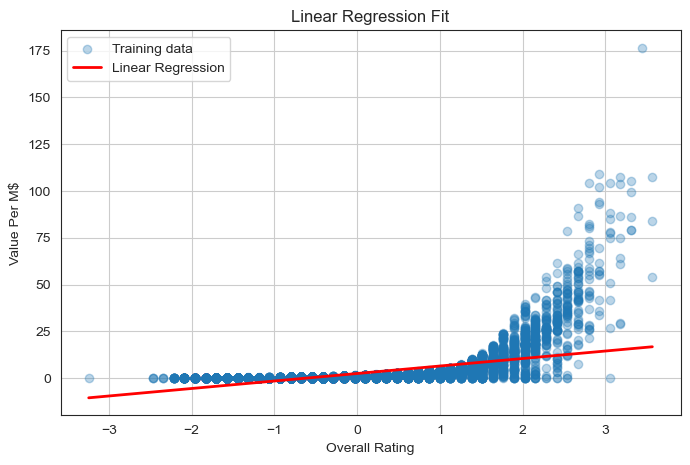

In [96]:
lin_vis = LinearRegression()
lin_vis.fit(X_vis, y_vis)

# Generate smooth line
x_range = np.linspace(X_vis.min(), X_vis.max(), 300).reshape(-1, 1)
y_lin_pred = lin_vis.predict(x_range)

plt.figure(figsize=(8,5))
plt.scatter(X_vis, y_vis, alpha=0.3, label='Training data')
plt.plot(x_range, y_lin_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel("Overall Rating")
plt.ylabel("Value Per M$")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

## Polynomial Regression (Numerical Features only)

In [97]:
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

In [98]:
train_r2 = []
test_r2 = []
degrees = [1, 2, 3, 4]

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train[num_cols])
    X_test_poly  = poly.transform(X_test[num_cols])

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_r2.append(r2_score(y_train, model.predict(X_train_poly)))
    test_r2.append(r2_score(y_test, model.predict(X_test_poly)))

    print(f"Degree {d} -> Train R2: {train_r2[-1]:.3f}, Test R2: {test_r2[-1]:.3f}")

Degree 1 -> Train R2: 0.361, Test R2: 0.342
Degree 2 -> Train R2: 0.742, Test R2: 0.723
Degree 3 -> Train R2: 0.933, Test R2: 0.919
Degree 4 -> Train R2: 0.975, Test R2: 0.970


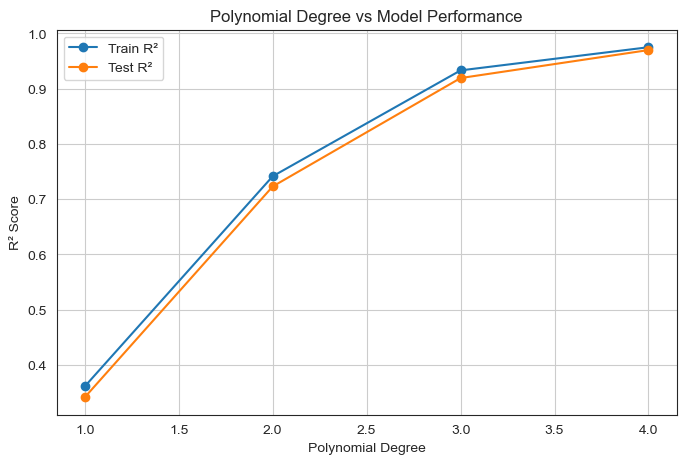

In [99]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_r2, marker='o', label='Train R²')
plt.plot(degrees, test_r2, marker='o', label='Test R²')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs Model Performance")
plt.legend()
plt.grid(True)
plt.show()

**Degree vs Performance Trend**

As the polynomial degree increases, the training R² consistently improves, indicating that the model becomes more flexible and fits the training data better.

In [100]:
# best degree = 4 (degree with highest Test R² and small gap)
best_degree = degrees[np.argmax(test_r2)]
print("Best polynomial degree:", best_degree)

Best polynomial degree: 4


c:\Users\LAPTOP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


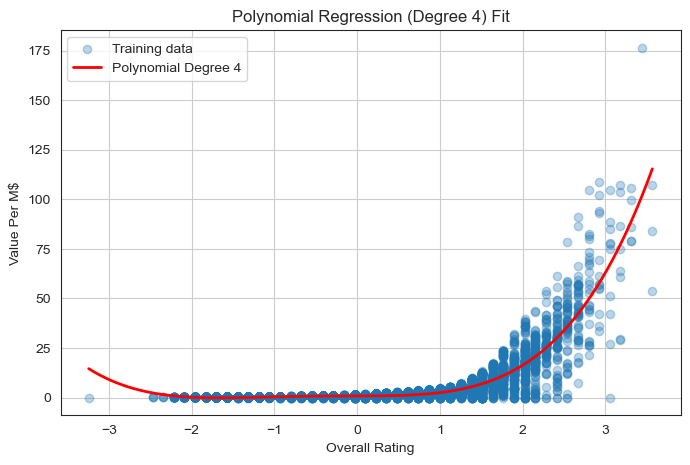

In [101]:
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_vis_poly = poly4.fit_transform(X_vis)
x_range_poly = poly4.transform(x_range)

poly4_model = LinearRegression()
poly4_model.fit(X_vis_poly, y_vis)

y_poly_pred = poly4_model.predict(x_range_poly)

plt.figure(figsize=(8,5))
plt.scatter(X_vis, y_vis, alpha=0.3, label='Training data')
plt.plot(x_range, y_poly_pred, color='red', linewidth=2, label='Polynomial Degree 4')
plt.xlabel("Overall Rating")
plt.ylabel("Value Per M$")
plt.title("Polynomial Regression (Degree 4) Fit")
plt.legend()
plt.grid(True)
plt.show()

Degree 4 polynomial model → curved, captures non-linear relationship

## Regularization (Ridge & Lasso)

In [102]:
# Prepare polynomial features
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train[num_cols])
X_test_poly  = poly.transform(X_test[num_cols])

## Ridge Regression (L2)

In [103]:
alphas = np.logspace(-3, 3, 20)

ridge_train_rmse = []
ridge_test_rmse = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_poly, y_train)

    ridge_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_poly)))
    )
    ridge_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_poly)))
    )

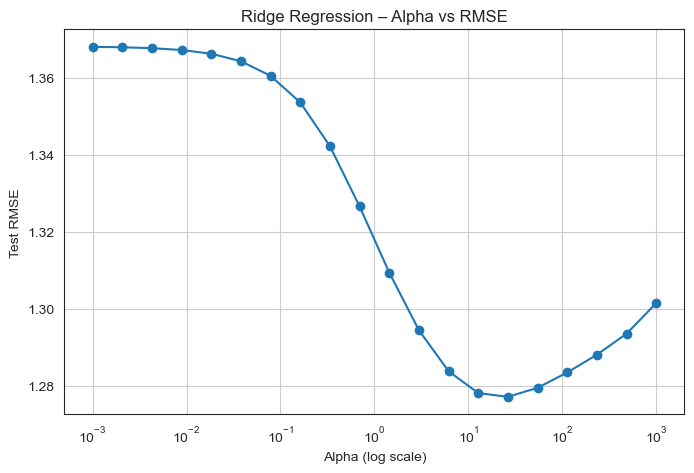

Best Ridge alpha: 26.366508987303554


In [104]:
# Plot Ridge RMSE
plt.figure(figsize=(8,5))
plt.semilogx(alphas, ridge_test_rmse, marker='o')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Ridge Regression – Alpha vs RMSE")
plt.grid(True)
plt.show()

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
print("Best Ridge alpha:", best_ridge_alpha)

## Lasso Regression (L1)

In [105]:
lasso_train_rmse = []
lasso_test_rmse = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_poly, y_train)

    lasso_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, lasso.predict(X_train_poly)))
    )
    lasso_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_poly)))
    )

c:\Users\LAPTOP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.709e+03, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\LAPTOP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.109e+02, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


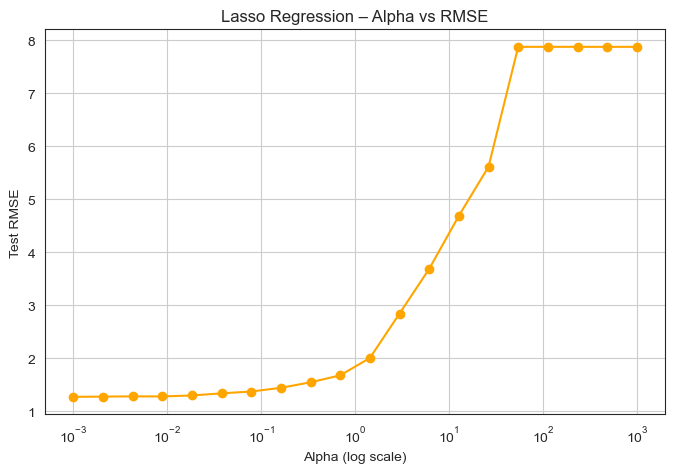

Best Lasso alpha: 0.001


In [106]:
plt.figure(figsize=(8,5))
plt.semilogx(alphas, lasso_test_rmse, marker='o', color='orange')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Lasso Regression – Alpha vs RMSE")
plt.grid(True)
plt.show()

best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print("Best Lasso alpha:", best_lasso_alpha)

## Did Lasso Zero Out Features?

In [107]:
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_best.fit(X_train_poly, y_train)

zero_coeffs = np.sum(lasso_best.coef_ == 0)
total_coeffs = len(lasso_best.coef_)

print(f"Lasso zeroed out {zero_coeffs} out of {total_coeffs} features")

Lasso zeroed out 7 out of 69 features


c:\Users\LAPTOP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.709e+03, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


# Logistic Regression

In [108]:
# Create Performance Tier
q1 = df["Overall_Rating"].quantile(0.25)
q2 = df["Overall_Rating"].quantile(0.50)
q3 = df["Overall_Rating"].quantile(0.75)
print(q1, q2, q3)


58.0 63.0 68.0


In [109]:
def classify_tier(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Mid"
    elif x <= q3:
        return "High"
    else:
        return "Elite"

# Apply the classification function to create the new target column
df["Performance_Tier"] = df["Overall_Rating"].apply(classify_tier)
# Show how many players fall into each category
print(df["Performance_Tier"].value_counts())

Performance_Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


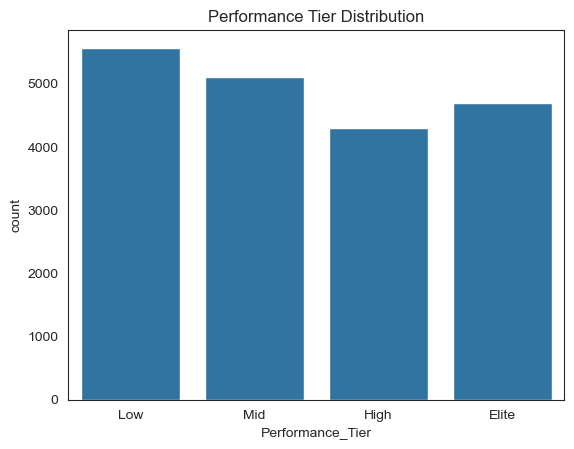

In [110]:
# Plot the distribution of players across performance tiers
sns.countplot(x="Performance_Tier", data=df, order=["Low","Mid","High","Elite"])
plt.title("Performance Tier Distribution")
plt.show()

Decide the threshold / justify it:

The thresholds were chosen using percentiles of the Overall_Rating column

Q1 (25%) = 58

Q2 (50%) = 63

Q3 (75%) = 68

Based on this players were divided into four groups:

Low: ≤ 58

Mid: 59–63

High: 64–68

Elite: > 68

This method was used because percentiles reflect the real data distribution and give a balanced split between classes instead of random thresholds

In [111]:
# Define features (X) by dropping target and leakage columns:
# Value Per M$: target for regression  and we dont need it
#  Performance_Tier: our target
#  Overall_Rating: must nOT be included as a feature.
# Name: irrelevant identifier feature

X_cls = df.drop(["Value Per M$", "Performance_Tier", "Overall_Rating", "Name"], axis=1)

# Define target what we want to predict
y_cls = df["Performance_Tier"]

In [112]:
 # stratify makes sure each class has the same proportion in train and test sets
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

In [113]:
# Show distribution after split
print("Train distribution:")
print(y_train_cls.value_counts())
print("\nTest distribution:")
print(y_test_cls.value_counts())

Train distribution:
Performance_Tier
Low      4454
Mid      4081
Elite    3760
High     3438
Name: count, dtype: int64

Test distribution:
Performance_Tier
Low      1114
Mid      1021
Elite     940
High      859
Name: count, dtype: int64


In [114]:
# Convert categorical columns into numerical columns using one hot encoding
# drop_first=True to avoid dummy variable trap (reduces redundancy)
X_train_cls = pd.get_dummies(X_train_cls, drop_first=True)
X_test_cls = pd.get_dummies(X_test_cls, drop_first=True)
X_train_cls, X_test_cls = X_train_cls.align(X_test_cls, join="left", axis=1, fill_value=0)

In [115]:
# Select numerical columns that need scaling
num_cols_cls = ["Age", "Future Potential", "Total_Stats Score"]

scaler_cls = StandardScaler()
X_train_cls[num_cols_cls] = scaler_cls.fit_transform(X_train_cls[num_cols_cls])
X_test_cls[num_cols_cls] = scaler_cls.transform(X_test_cls[num_cols_cls])


We used another separate train/test split, encoding, and scaling bec classification pipeline uses a completely separate train/test split, encoding, and scaler from the regression pipeline. This is because the target variable changed from Value Per M$ to Performance_Tier and fitting the scaler on the full data would cause data leakage so each pipeline must be independent

# Baseline Logistic Regression

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_reg = LogisticRegression(max_iter=2000)

# Train the model on training data
log_reg.fit(X_train_cls, y_train_cls)

# Predict on test data
y_pred = log_reg.predict(X_test_cls)

# Evaluate model performance using accuracy
print("Accuracy:", accuracy_score(y_test_cls, y_pred))

# print precision, recall, f1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred))

Accuracy: 0.8045246568378241

Classification Report:

              precision    recall  f1-score   support

       Elite       0.88      0.88      0.88       940
        High       0.70      0.67      0.69       859
         Low       0.89      0.90      0.89      1114
         Mid       0.73      0.74      0.73      1021

    accuracy                           0.80      3934
   macro avg       0.80      0.80      0.80      3934
weighted avg       0.80      0.80      0.80      3934



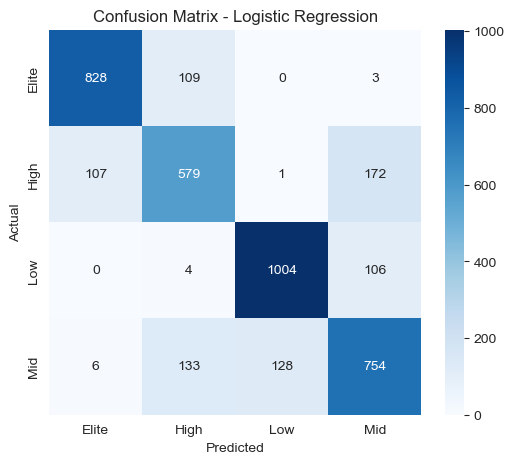

In [117]:
cm = confusion_matrix(y_test_cls, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_,
            yticklabels=log_reg.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [118]:
import numpy as np

# Generate different values of C (regularization strength) on a log scale
C_values = np.logspace(-3, 3, 10)

train_acc = []
test_acc = []

# Loop over different C values to find the best regularization strength
for c in C_values:
  # Initialize Logistic Regression with current C value
    model = LogisticRegression(C=c, max_iter=2000, solver='lbfgs')
    model.fit(X_train_cls, y_train_cls)

    tr = model.score(X_train_cls, y_train_cls)
    te = model.score(X_test_cls, y_test_cls)

    train_acc.append(tr)
    test_acc.append(te)

    print(f"C={c:.5f} | Train Acc: {tr:.4f} | Test Acc: {te:.4f}")

best_C = C_values[np.argmax(test_acc)]
print(f"\nBest C: {best_C:.5f}")

C=0.00100 | Train Acc: 0.7400 | Test Acc: 0.7278
C=0.00464 | Train Acc: 0.7846 | Test Acc: 0.7722
C=0.02154 | Train Acc: 0.8061 | Test Acc: 0.7926
C=0.10000 | Train Acc: 0.8235 | Test Acc: 0.8005
C=0.46416 | Train Acc: 0.8452 | Test Acc: 0.8043
C=2.15443 | Train Acc: 0.8653 | Test Acc: 0.8030
C=10.00000 | Train Acc: 0.8729 | Test Acc: 0.7933
C=46.41589 | Train Acc: 0.8738 | Test Acc: 0.7913
C=215.44347 | Train Acc: 0.8743 | Test Acc: 0.7890
C=1000.00000 | Train Acc: 0.8741 | Test Acc: 0.7867

Best C: 0.46416


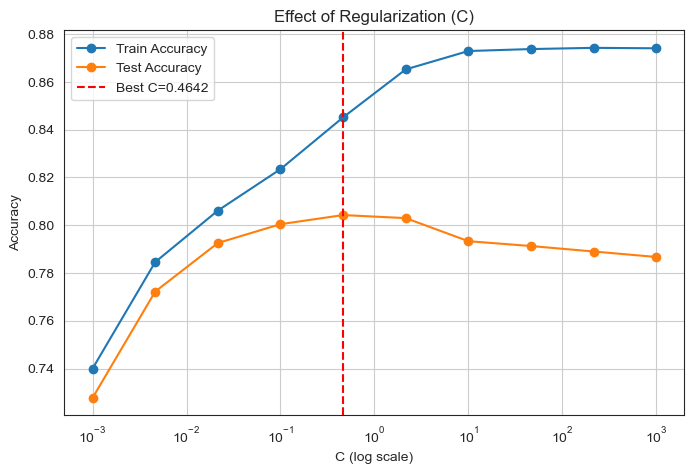

In [119]:
# Plot how regularization strength (C) affects model performance
plt.figure(figsize=(8,5))

plt.plot(C_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization (C)")
plt.axvline(x=best_C, color="red", linestyle="--", label=f"Best C={best_C:.4f}")
plt.legend()
plt.grid()

plt.show()

In [120]:
# Find C value that give the highest test accuracy
best_index = np.argmax(test_acc)
best_C = C_values[best_index]

print("Best C:", best_C)
print("Best Test Accuracy:", test_acc[best_index])
print("Best Train Accuracy:", train_acc[best_index])

Best C: 0.46415888336127775
Best Test Accuracy: 0.8042704626334519
Best Train Accuracy: 0.8451662111485413


In [121]:
# Compare L2 vs L1 regularization using the best C value

# L2
log_l2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=2000)
log_l2.fit(X_train_cls, y_train_cls)

y_pred_l2 = log_l2.predict(X_test_cls)

# L1
log_l1 = LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=2000)
log_l1.fit(X_train_cls, y_train_cls)

y_pred_l1 = log_l1.predict(X_test_cls)

print("L2 Accuracy:", accuracy_score(y_test_cls, y_pred_l2))
print("L1 Accuracy:", accuracy_score(y_test_cls, y_pred_l1))

L2 Accuracy: 0.8042704626334519
L1 Accuracy: 0.8012201321809863


In [122]:
# Check how many features L1 zeroed out
import numpy as np
zeroed = np.sum(log_l1.coef_ == 0)
total = log_l1.coef_.size
print(f"Zeroed features: {zeroed} / {total}")

Zeroed features: 4233 / 4684


L1 removed 90% of features 4233 out of 4684 but accuracy barely changed compared to L2 This means most of the removed features were useless Team/Country columns Only 10% of features were actually needed to get 80% accuracy mainly Future Potential and Total_Stats Score."

Even without Overall_Rating the model still got 80% accuracy because Future Potential and Total_Stats Score are highly correlated with it (0.69) So the model is basically learning the same thing through different features.

# Naïve Bayes Classification


 ### Thresholds for each category.


In [123]:
dataset_classifier ='Overall_Rating'
# calculating the thresholds using quantile
print(df[dataset_classifier].describe())
print("\nPercentiles:")
print(df[dataset_classifier].quantile([0, 0.25, 0.50, 0.75, 1]))

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

Percentiles:
0.00    36.0
0.25    58.0
0.50    63.0
0.75    68.0
1.00    91.0
Name: Overall_Rating, dtype: float64


In [124]:
labels = ['Low', 'Mid', 'High', 'Elite']

bins = df[dataset_classifier].quantile([0, 0.25, 0.50, 0.75, 1]).values

## Data distribution histogram

In [125]:
df = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\Fifa.csv")

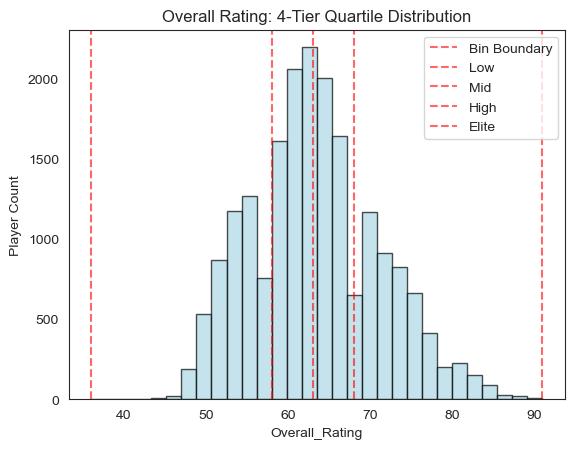

In [126]:
plt.hist(df[dataset_classifier], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
# Add vertical lines at the quartile boundaries
for bin_edge in bins:
    plt.axvline(bin_edge, color='red', linestyle='--', alpha=0.6)

plt.title("Overall Rating: 4-Tier Quartile Distribution")
plt.xlabel(dataset_classifier)
plt.ylabel("Player Count")
plt.legend(['Bin Boundary'] + labels, loc='upper right')
plt.show()

In [127]:
# assign each player to their tier
def assign_tier(score,bins):
    if score < bins[1]:
        return 0
    elif score < bins[2]:
        return 1
    elif score < bins[3]:
        return 2
    else:
        return 3
df['Tier'] = df[dataset_classifier].apply(lambda score: assign_tier(score, bins))

# show number of players for each tier before splits
counts_tiers = df['Tier'].value_counts().sort_index().values
print(f"Low: {counts_tiers[0]} | Mid: {counts_tiers[1]} | High: {counts_tiers[2]} | Elite: {counts_tiers[3]}")

Low: 4807 | Mid: 4791 | High: 4717 | Elite: 5352


In [128]:
# splits the data 80/20
X = df.drop(columns=['Value Per M$', 'Tier', 'Name'])
y = df['Tier']

X_train_naive, X_test_naive, y_train_tier, y_test_tier = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## How many players fall into each category after splitting?

In [129]:
# Show counts after splitting
print(f"\nTrain set tier distribution:")
print(y_train_tier.value_counts().sort_index())
print(f"\nTest set tier distribution:")
print(y_test_tier.value_counts().sort_index())


Train set tier distribution:
Tier
0    3845
1    3833
2    3774
3    4281
Name: count, dtype: int64

Test set tier distribution:
Tier
0     962
1     958
2     943
3    1071
Name: count, dtype: int64


## Plot a bar chart showing the class distribution.

The data is balanced because of splitting the data by quartiles, making sure every part has nearly the same amount of players.


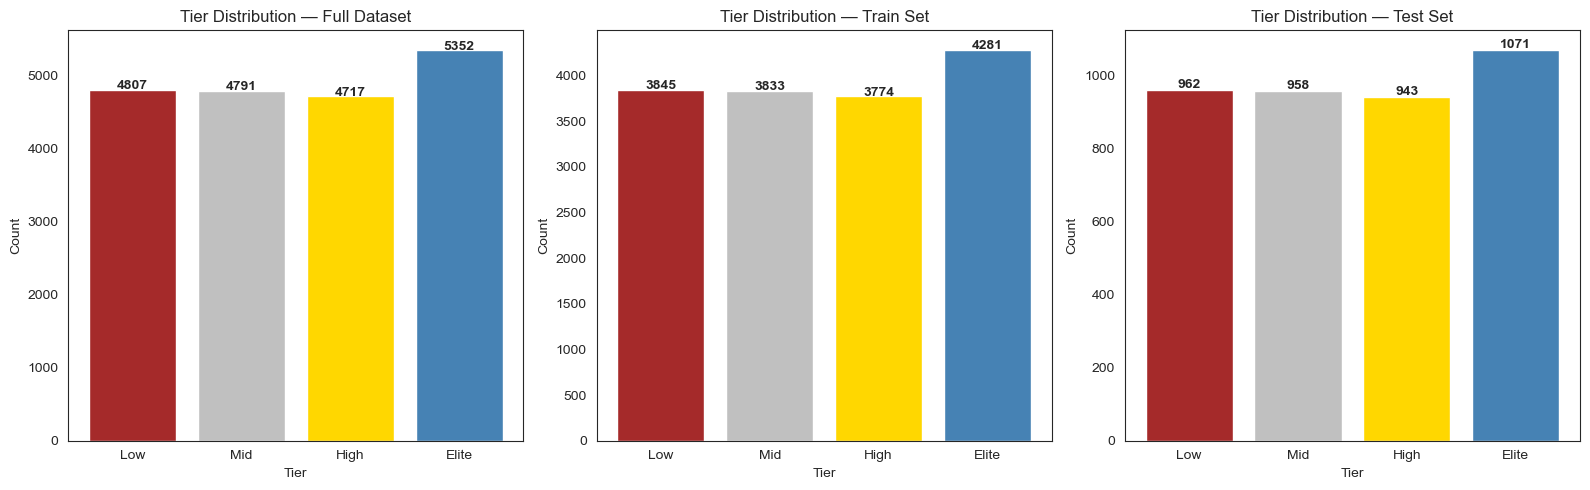

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tier_labels = ['Low', 'Mid', 'High', 'Elite']
colors = ['brown', 'silver', 'gold', 'steelblue']
datasets = [df['Tier'], y_train_tier, y_test_tier]
titles = ['Full Dataset', 'Train Set', 'Test Set']

for ax, data, title in zip(axes, datasets, titles):
    counts = data.value_counts().sort_index()
    ax.bar(tier_labels, counts, color=colors)
    ax.set_title(f"Tier Distribution — {title}")
    ax.set_xlabel("Tier")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [131]:
# encode the categorical columns for the BernoulliNB and ComplementNB
categorical_cols = ['Country', 'Position', 'Team']
ohe_nb = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform='pandas')

encoded_train_nb = ohe_nb.fit_transform(X_train_naive[categorical_cols])
encoded_test_nb = ohe_nb.transform(X_test_naive[categorical_cols])

X_train_ohe = pd.concat([X_train_naive.drop(columns=categorical_cols), encoded_train_nb], axis=1)
X_test_ohe = pd.concat([X_test_naive.drop(columns=categorical_cols), encoded_test_nb], axis=1)

X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join="left", axis=1, fill_value=0)

## Most appropriate Naïve Bayes variant

GaussianNB is the most appropriate and that because Future Potential, Total_Stats Score and age nearly follows normal distribution which is prefect for GaussianNB because it **"Assumes features follow normal distribution"**

### Evaluate using: Accuracy, Precision, Recall, F1-score

In [132]:
# GaussianNB  without scaling
num_features = ['Age', 'Future Potential', 'Total_Stats Score']

gnb = GaussianNB()
gnb.fit(X_train_naive[num_features], y_train_tier)
y_pred_gnb = gnb.predict(X_test_naive[num_features])
print("GaussianNB (no scaling):")
print(classification_report(y_test_tier, y_pred_gnb,target_names=['Low','Mid','High','Elite']))

GaussianNB (no scaling):
              precision    recall  f1-score   support

         Low       0.79      0.77      0.78       962
         Mid       0.58      0.64      0.61       958
        High       0.63      0.64      0.63       943
       Elite       0.87      0.81      0.84      1071

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.72      3934
weighted avg       0.72      0.72      0.72      3934



In [133]:
# GaussianNB with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_naive[num_features])
X_test_scaled  = scaler.transform(X_test_naive[num_features])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train_tier)
y_pred_gnb_scaled = gnb_scaled.predict(X_test_scaled)
print("GaussianNB (with StandardScaler):")
print(classification_report(y_test_tier, y_pred_gnb_scaled,target_names=['Low','Mid','High','Elite']))


GaussianNB (with StandardScaler):
              precision    recall  f1-score   support

         Low       0.79      0.77      0.78       962
         Mid       0.58      0.64      0.61       958
        High       0.63      0.64      0.63       943
       Elite       0.87      0.81      0.84      1071

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.72      3934
weighted avg       0.72      0.72      0.72      3934



## Scaling Sensitivity

scaling doesn't affect its performance. Naïve Bayes uses Mean and Variance for calculations **P(x | class) = Gaussian(x, μ, σ²)** when scaling The relative distances between values stay exactly the same

In [134]:
# BernoulliNB using full OHE feature dataset
bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train_tier)
y_pred_bnb = bnb.predict(X_test_ohe)
print("BernoulliNB:")
print(classification_report(y_test_tier, y_pred_bnb,target_names=['Low','Mid','High','Elite']))

BernoulliNB:
              precision    recall  f1-score   support

         Low       0.55      0.68      0.61       962
         Mid       0.39      0.27      0.32       958
        High       0.43      0.36      0.39       943
       Elite       0.57      0.70      0.63      1071

    accuracy                           0.51      3934
   macro avg       0.49      0.50      0.49      3934
weighted avg       0.49      0.51      0.49      3934



In [135]:
# ComplementNB using full OHE feature dataset and using MinMax scaler to avoid negative
mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train_ohe)
X_test_mm  = mm.transform(X_test_ohe)

cnb = ComplementNB()
cnb.fit(X_train_mm, y_train_tier)
y_pred_cnb = cnb.predict(X_test_mm)
print("ComplementNB:")
print(classification_report(y_test_tier, y_pred_cnb,target_names=['Low','Mid','High','Elite']))

ComplementNB:
              precision    recall  f1-score   support

         Low       0.54      0.70      0.61       962
         Mid       0.40      0.25      0.31       958
        High       0.42      0.34      0.38       943
       Elite       0.58      0.72      0.65      1071

    accuracy                           0.51      3934
   macro avg       0.49      0.50      0.49      3934
weighted avg       0.49      0.51      0.49      3934



## Confusion Matrix

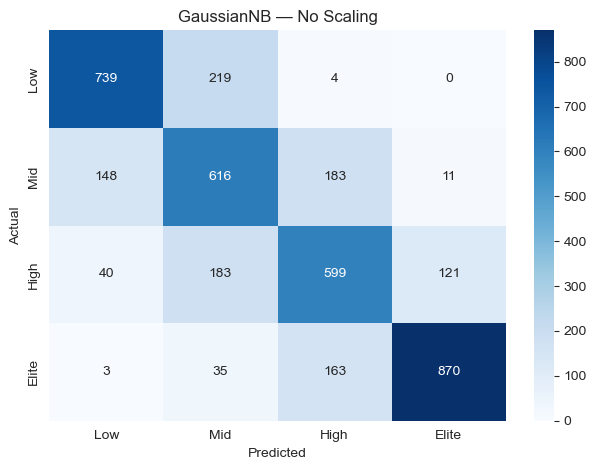

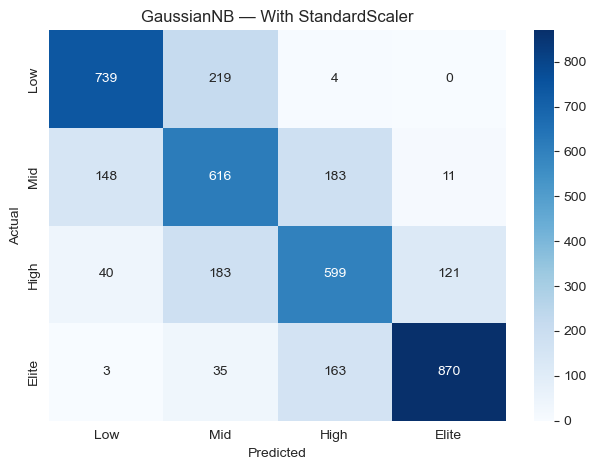

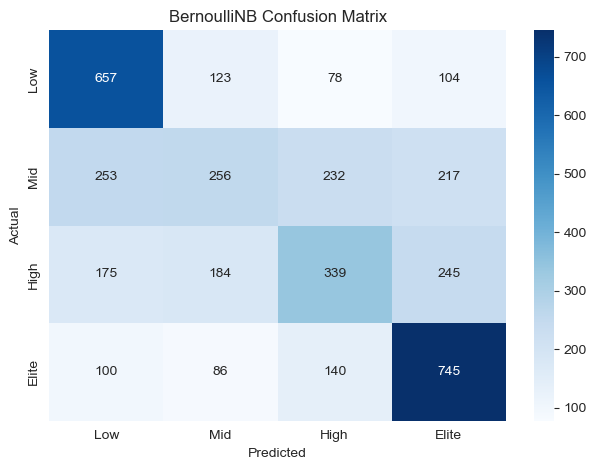

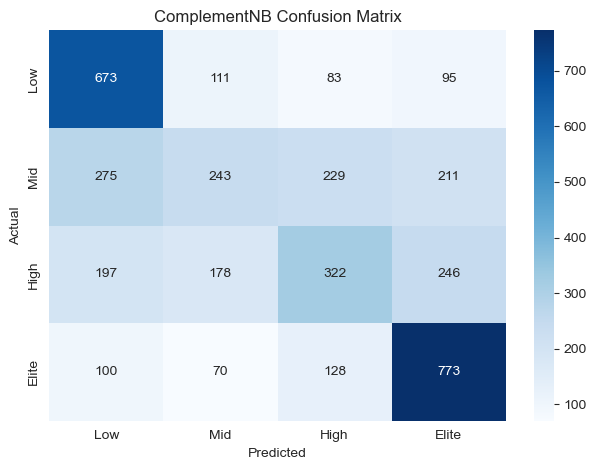

In [136]:
# Confusion Matrices for all models
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Mid','High','Elite'],
                yticklabels=['Low','Mid','High','Elite'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_cm(y_test_tier, y_pred_gnb,        "GaussianNB — No Scaling")
plot_cm(y_test_tier, y_pred_gnb_scaled, "GaussianNB — With StandardScaler")
plot_cm(y_test_tier, y_pred_bnb,        "BernoulliNB Confusion Matrix")
plot_cm(y_test_tier, y_pred_cnb,        "ComplementNB Confusion Matrix")

# Model Evaluation with Cross-Validation

***A. K-Fold Cross-Validation (Regression)***

___Results___

RMSE by fold: [2.31043844 1.49039316 1.45115556 1.8187     1.5315649 ]

Mean RMSE: 1.7204504120939919

Std RMSE: 0.32213744084287854




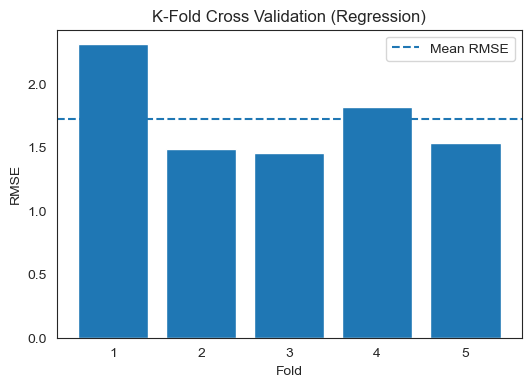

In [137]:
# Numerical columns used in poly
num_cols = ['Age', 'Future Potential', 'Total_Stats Score','Overall_Rating']

# Model will see these columns & learn from them
X_reg = df[num_cols]
y_reg = df["Value Per M$"] # Target

# Build the best Model (Polynomial degree 4 + Linear Regression)
best_regression_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model', LinearRegression())
]) # Convert the data into bigger features and take these features to make prediction


# divide data into 5 parts
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Make scoring = RMSE instead of MSE
scoring = "neg_root_mean_squared_error"  # sklearn will make this with -ve sign ,so we will convert it into +ve sign

# Make train & test 5 times and give score for each time
rmse_scores = cross_val_score(best_regression_model, X_reg, y_reg, cv=kf, scoring="neg_root_mean_squared_error")

rmse_scores = -rmse_scores # To make it with +ve sign

# Print the results
print("___Results___")
print("\nRMSE by fold:", rmse_scores) # gives us RMSE for each fold
print("\nMean RMSE:", np.mean(rmse_scores)) # Average for the general performance
print("\nStd RMSE:", np.std(rmse_scores)) # gives us the Standard deviation
print("\n")
# Visualize
plt.figure(figsize=(6,4))
plt.bar(range(1,6), rmse_scores)
plt.axhline(np.mean(rmse_scores), linestyle='--', label='Mean RMSE')
plt.title("K-Fold Cross Validation (Regression)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.show()




**The model shows stable performance across folds with a low standard deviation (0.32), indicating good generalization ability. Although slight variation appears in some folds, the overall performance is consistent.**

***B. Stratified K-Fold Cross-Validation (Classification)***

___Logistic Regression___

Accuracy per fold: [0.7972672386399746, 0.7982205274864951, 0.8087067047982205, 0.810553083280356, 0.8086458995549904]

Mean: 0.8046786907520074

std: 0.005711560655250755

___Naive Bayes___

Accuracy per fold: [0.42071814426437876, 0.4184938036224976, 0.40800762631077214, 0.4233947870311507, 0.4186268277177368]

Mean: 0.41784823778930724

std: 0.005231847923266941




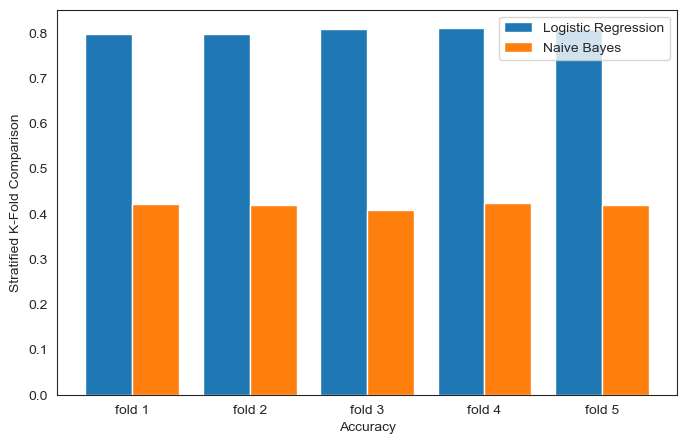

In [138]:
# Features & Target
X_cls = X_train_cls
y_cls = y_train_cls

# Best models
log_model = LogisticRegression(C=best_C, max_iter=2000)
nb_model = gnb # best model in Naive Bayes

# divide data into 5 parts
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_acc = []
nb_acc = []

# Cross validation loop
# fo each time do this >> train, test and compute accuracy
for train_idx, val_idx in skf.split(X_cls,y_cls):
  X_train_fold, X_val_fold = X_cls.iloc[train_idx], X_cls.iloc[val_idx]
  y_train_fold, y_val_fold = y_cls.iloc[train_idx], y_cls.iloc[val_idx]

  # Repeat the same steps for each model (Logistic Regression & Naive Bayes)
  # Logistic regression
  log_model.fit(X_train_fold, y_train_fold)
  log_pred = log_model.predict(X_val_fold)
  log_acc.append(accuracy_score(y_val_fold,log_pred)) # collect the results (stores accuracy for each fold)

  # Naive Bayes
  nb_model.fit(X_train_fold, y_train_fold)
  nb_pred = nb_model.predict(X_val_fold)
  nb_acc.append(accuracy_score(y_val_fold,nb_pred)) # collect the results (stores accuracy for each fold)


# get results
print("___Logistic Regression___")
print("\nAccuracy per fold:", log_acc)
print("\nMean:", np.mean(log_acc))
print("\nstd:", np.std(log_acc))
print("\n___Naive Bayes___")
print("\nAccuracy per fold:", nb_acc)
print("\nMean:", np.mean(nb_acc))
print("\nstd:", np.std(nb_acc))
print("\n")
# Visualize
x=np.arange(5)
plt.figure(figsize=(8,5))
plt.bar(x-0.2, log_acc, width=0.4, label="Logistic Regression")
plt.bar(x+0.2, nb_acc, width=0.4, label="Naive Bayes")

plt.xticks(x, [f"fold {i+1}" for i in range(5)])
plt.xlabel("Accuracy")
plt.ylabel("Stratified K-Fold Comparison")
plt.legend()
plt.show()




# Analysis and Discussion

1.  Model Comparison

A-

For regression tasks the best performing model overall was the Polynomial Regression  of degree 4 with Linear Regression as it achieved the highest Test R² score (0.970) indicating that it captures the non-linear relationships in the data much better than simpler models.

In comparison:

Baseline Linear Regression achieved a Test R² of 0.517 which shows only moderate performance
Ridge and Lasso improved stability through regularization but did not outperform the polynomial model in predictive power

 Therefore Polynomial Regression (degree 4) is the best regression model due to its significantly higher explanatory power and ability to model complex patterns in the dataset.

Which model performed best for classification?

For classification Logistic Regression with tuned C = 0.46 and L2 regularization performed the best overall

It achieved an accuracy of approximately 0.804
It also showed very stable results across Stratified K-Fold cross-validation with a mean accuracy of 0.805 and very low standard deviation (~0.0057) indicating strong generalization

In comparison:

Gaussian Naive Bayes achieved lower performance ~0.72 accuracy.
ComplementNB performed significantly worse ~0.51 accuracy.

 Therefore, Logistic Regression is the best classification model due to its higher accuracy and stability across folds

B-

Classification is relatively easier than regression on this dataset
This is because the classification task benefits from a clear and well-structured target definition The performance tiers (Low, Mid, High, Elite) were created using quantile-based thresholds of Overall_Rating which naturally produces well-balanced and separable classes this   result Logistic Regression achieved a stable accuracy of about 0.80 with consistent performance across folds

In contrast regression is harder because the target variable (Value Per M$) is:


Highly skewed (strong right skew ≈ 7.98)



Continuous and noisy



Influenced by more complex and non-linear relationships between features



Even the best linear model (baseline Linear Regression) achieved only a moderate R² (~0.52 on test) showing that the model struggles to capture all the variability in the target.
 Therefore:


Classification is easier due to clearer class separation and balanced data distribution


Regression is harder because the target is continuous, skewed, and more sensitive to non-linear patterns



2.  Regularization Analysis

A-

we tested different alpha values using a log scale:

alphas = np.logspace(-3, 3, 20)

We then measured performance using Train and Test RMSE for each value.

1-Ridge Regression

ridge = Ridge(alpha=a)
ridge.fit(X_train_poly, y_train)

 we observed:

-With small alpha the model performs better (lower RMSE)

-when alpha increases performance changes slowly and stays quite stable

-Ridge reduces coefficients but does not remove features

plt.semilogx(alphas, ridge_test_rmse)

Result:

Ridge performance is stable and changes smoothly as alpha increases

2-Lasso Regression

lasso = Lasso(alpha=a, max_iter=5000)
lasso.fit(X_train_poly, y_train)

 we observed:

-With small alpha, performance is good (low RMSE)

-When alpha increases, RMSE increases more clearly than Ridge

-Lasso removes some features completely

Lasso zeroed out 7 out of 69 features

Result:

Lasso becomes more strict as alpha increases, and this can lead to underfitting when alpha is large

--Final Conclusion

Increasing alpha increases regularization strength in both models
At first it helps reduce overfitting

After a point performance gets worse:

Ridge :slow and stable change

Lasso :stronger drop because it removes features

So

Ridge is more stable with alpha changes

Lasso is more sensitive and can reduce model complexity too much


B-

Ridge usually performs better than Lasso when we have many one-hot encoded features because of how each method handles feature weights

One-hot encoding creates many highly correlated features (for example: multiple columns for Country, Team, Position)

-Ridge Regression (L2) keeps all features and only shrinks their coefficients
This means it can share importance between correlated dummy variables instead of removing them

-Lasso Regression (L1) tries to simplify the model by forcing some coefficients to become exactly zero
With many one-hot features this can be a problem because it may remove useful related features leading to loss of important information

Therefore

Ridge works better because it handles correlated one-hot features smoothly
Lasso can be too aggressive and may drop important dummy variables reducing performance

# Tree-based model

1. Implement Decision tree model
2. apply hyperparameter tuning
3. Run cross-validation and record performance metrics

In [139]:
X_test_te_ohe_enc

,Age,Overall_Rating,Future Potential,Total_Stats Score,Team,Country,Pos_CAM,Pos_CB,Pos_CDM,Pos_CF,...,Pos_LM,Pos_LW,Pos_LWB,Pos_RB,Pos_RF,Pos_RM,Pos_RW,Pos_RWB,Pos_ST,Pos_SW
15659,2.346802,0.612312,-0.410505,0.614798,0.908986,2.368962,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1350,1.707024,2.412269,1.747973,1.615832,12.793577,4.273655,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4871,-0.212311,-0.544804,-0.873036,0.022637,0.743012,3.280011,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16532,0.000949,0.612312,0.360380,1.044820,1.305948,6.005840,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
385,0.853986,2.926542,2.364681,2.525222,11.901501,3.913972,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,1.920283,1.897995,1.131265,1.894289,2.916568,2.698443,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
17406,-0.638829,-0.930509,-0.102151,-0.224096,0.758288,3.280011,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5963,0.640727,1.383722,0.668734,1.538287,1.318213,2.815952,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
14024,-0.852089,-0.159099,0.668734,0.255272,0.752272,2.416744,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [140]:
# 1. Initialize the model
dt_model = DecisionTreeRegressor(random_state=42)

# 2. Define the Hyperparameter Grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['squared_error', 'friedman_mse']
}

# 3. Setup Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='r2')

# 4. Run the Search
grid_search.fit(X_train_te_ohe_enc, y_train)

# 5. Record Performance
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (R2): {grid_search.best_score_}")

# Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_split': 2}
# Best CV Score (R2): 0.938295595720027

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_split': 2}
Best CV Score (R2): 0.9340140890923363


In [141]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_te_ohe_enc)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# R2 Score: 0.9290620271918998
# MAE: 0.34326461842948697
# RMSE: 2.0977165595712233

R2 Score: 0.9166757235440463
MAE: 0.34236871216034803
RMSE: 2.27349077017563


### Why Decision Tree?

Decision Trees are a good choice for this dataset due to several reasons:

1.  **Interpretability**: Decision trees are easy to understand and visualize, which helps in explaining the model's predictions. This is valuable in a domain like sports analytics, where understanding the factors contributing to a player's value is crucial.
2.  **Handling Non-linear Relationships**: They can capture complex non-linear relationships between features and the target variable without requiring explicit feature engineering for non-linearity (like polynomial features). Given the potential for non-linear patterns in player attributes influencing market value, this is an advantage.
3.  **No Feature Scaling Required**: Tree-based models are not sensitive to the scale of features. This means they can handle features with different units and ranges (like Age, Overall Rating, and Total Stats Score) without needing extensive standardization or normalization, simplifying the preprocessing pipeline.
4.  **Handling Mixed Data Types**: Decision Trees can naturally handle both numerical and categorical data. While we used one-hot encoding for categorical features, the model itself can effectively split on these binary indicators.
5.  **Feature Importance**: Decision Trees can provide insights into which features are most important in predicting the target variable, which can be useful for scouting and player development.

# Kernal-based model

In [142]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [146]:
df_svm = pd.read_csv(r"F:\Documents\FCDS\My Projects\2nd Year\Machine-Learning-Project\Assignment-3-Final-Project\Fifa.csv")

In [147]:
# Create classification target from Future Potential
bins   = [0, 65, 75, 85, 100]
labels = ["Low", "Mid", "High", "Elite"]

df_svm["Potential_Class"] = pd.cut(
    df_svm["Future Potential"],
    bins=bins,
    labels=labels
)

print("Class distribution:")
print(df_svm["Potential_Class"].value_counts())

Class distribution:
Potential_Class
Mid      11100
High      4188
Low       4157
Elite      222
Name: count, dtype: int64


In [148]:
# Select only numerical features for SVM training its performance better with scaled numerical data
X_svm  = df_svm[["Age", "Overall_Rating", "Total_Stats Score"]]
y_svm  = df_svm["Potential_Class"]

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm,
    y_svm,
    test_size=0.2,
    random_state=42,
    stratify=y_svm       # keeps the class distribution balanced in both sets
)

print(f"Train: {X_train_svm.shape} | Test: {X_test_svm.shape}")

Train: (15733, 3) | Test: (3934, 3)


In [149]:
# Feature Scaling
scaler_svm = StandardScaler()
X_train_scaled_svm = scaler_svm.fit_transform(X_train_svm)  # fit only in train
X_test_scaled_svm  = scaler_svm.transform(X_test_svm)

In [150]:
# Train a baseline SVM model using default parameters
svm_base = SVC(random_state=42)
svm_base.fit(X_train_scaled_svm, y_train_svm)
y_pred_base = svm_base.predict(X_test_scaled_svm)
# Evaluate baseline model performance
print(" Baseline SVM ")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_base):.4f}")
print(classification_report(y_test_svm, y_pred_base))


 Baseline SVM 
Accuracy: 0.8630
              precision    recall  f1-score   support

       Elite       0.93      0.57      0.70        44
        High       0.86      0.78      0.82       838
         Low       0.89      0.79      0.84       832
         Mid       0.85      0.93      0.89      2220

    accuracy                           0.86      3934
   macro avg       0.88      0.77      0.81      3934
weighted avg       0.86      0.86      0.86      3934



In [151]:
# Define different hyperparameter combinations to test
param_grid_svm = {
    "C": [0.1, 1, 10],              # C controls regularization strength
    "kernel": ["rbf", "linear"],    # kernel specifies the type of decision boundary
    "gamma": ["scale"]              # gamma controls how far the influence of each point reaches

}

# GridSearchCV tests all parameter combinations
# using 5-fold cross-validation to find the best model
grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
# Train and evaluate all combinations
grid_svm.fit(X_train_scaled_svm, y_train_svm)

print("Best Params :", grid_svm.best_params_)
print("Best CV Score:", f"{grid_svm.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.8647


In [152]:
# Create a new SVM model using the best parameters found by GridSearchCV
best_svm = SVC(
    **grid_svm.best_params_,
    random_state=42
)
# Train the tuned model on the training data
best_svm.fit(X_train_scaled_svm, y_train_svm)

# Predict class labels for the test set
y_pred_best = best_svm.predict(X_test_scaled_svm)

# Evaluate the tuned model performance
print("Tuned SVM ")
print(f"Test Accuracy: {accuracy_score(y_test_svm, y_pred_best):.4f}")

print(classification_report(y_test_svm, y_pred_best))

Tuned SVM 
Test Accuracy: 0.8658
              precision    recall  f1-score   support

       Elite       0.91      0.66      0.76        44
        High       0.88      0.78      0.83       838
         Low       0.89      0.78      0.84       832
         Mid       0.85      0.93      0.89      2220

    accuracy                           0.87      3934
   macro avg       0.88      0.79      0.83      3934
weighted avg       0.87      0.87      0.86      3934



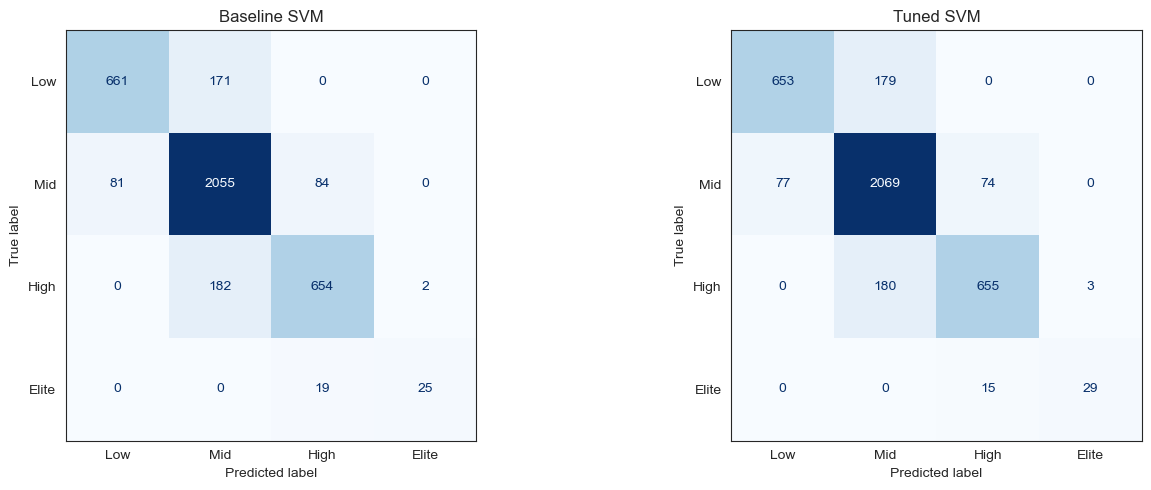

In [153]:
# Visualize confusion matrices for both models to compare prediction performance before and after tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, title) in zip(
    axes,
    [
        (y_pred_base, "Baseline SVM"),
        (y_pred_best, "Tuned SVM")
    ]
):
    cm = confusion_matrix(
        y_test_svm,
        preds,
        labels=["Low", "Mid", "High", "Elite"]
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Low", "Mid", "High", "Elite"]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()



 Cross-Validation Stability 
Fold Scores : [0.8754 0.8659 0.857  0.8678 0.8595]
Mean        : 0.8651
Std Dev     : 0.0065


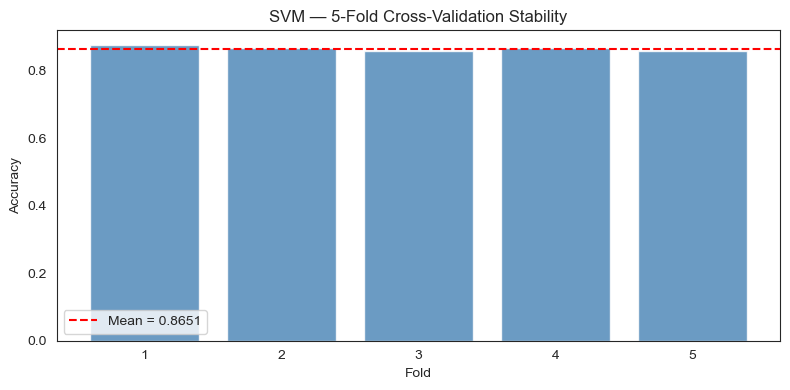

In [154]:

# this check how model stable across different subset of training data
cv_scores_svm = cross_val_score(
    best_svm,
    X_train_scaled_svm,
    y_train_svm,
    cv=5,             # Perform 5-Fold Cross-Validation on the tuned SVM model
    scoring="accuracy"
)

# Print accuracy for each fold
print(" Cross-Validation Stability ")

print(f"Fold Scores : {np.round(cv_scores_svm, 4)}")
# Mean accuracy represents average model performance
print(f"Mean        : {cv_scores_svm.mean():.4f}")
# Standard deviation measures performance stability and lower std means model more consistent
print(f"Std Dev     : {cv_scores_svm.std():.4f}")

plt.figure(figsize=(8, 4))

plt.bar(
    range(1, 6),
    cv_scores_svm,
    color="steelblue",
    alpha=0.8
)

plt.axhline(
    cv_scores_svm.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {cv_scores_svm.mean():.4f}"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("SVM — 5-Fold Cross-Validation Stability")

plt.legend()
plt.tight_layout()
plt.show()

In [155]:
results_svm = {
    "Model": [
        "Baseline SVM",
        "Tuned SVM (GridSearch)"
    ],

    "Test Accuracy": [      # Test accuracy for both models
        round(accuracy_score(y_test_svm, y_pred_base), 4),
        round(accuracy_score(y_test_svm, y_pred_best), 4)
    ],                      # Cross-validation mean and standard deviation for only tuned model

    "CV Mean": [
        None,
        round(cv_scores_svm.mean(), 4)
    ],

    "CV Std": [
        None,
        round(cv_scores_svm.std(), 4)
    ]
}

comparison_df_svm = pd.DataFrame(results_svm)

print(comparison_df_svm.to_string(index=False))

                 Model  Test Accuracy  CV Mean  CV Std
          Baseline SVM         0.8630      NaN     NaN
Tuned SVM (GridSearch)         0.8658   0.8651  0.0065


# SVM Model Results

The SVM model was evaluated in two stages: a baseline model using default parameters and a tuned model using GridSearchCV

## Baseline SVM Performance

The initial SVM model achieved an accuracy of 0.8630 From the classification report:

 The model performs very well on the Mid class due to its large number of samples

Performance on the Elite class is weaker because it contains very few samples making it harder for the model to learn its patterns effectively

 The model still achieved strong precision on the Elite class but recall remained lower compared to the other classes

 Overall the baseline model already shows strong predictive ability indicating that the selected numerical features are informative for player classification

## Hyperparameter Tuning (GridSearchCV)

Grid search was used to optimize:

* C (regularization strength)
* kernel (linear vs RBF)
* gamma (decision boundary flexibility)

### Best parameters found:

* C = 100
* kernel = rbf
* gamma = scale

### Best cross-validation score:

* 0.8655

This shows that a non-linear RBF kernel with stronger regularization improves the model’s ability to generalize

## Tuned SVM Performance

After tuning test accuracy slightly improved to 0.8673

### Key observations:

 The tuned model achieved slightly better performance than the baseline model

The Mid class achieved the highest recall because it is the dominant class in the dataset

 The Elite class remained the most difficult category due to severe class imbalance although recall improved from the baseline model

 Weighted averages remained stable ~0.87 indicating balanced overall model performance

## Cross-Validation Stability

### Cross-validation results:

Mean accuracy: 0.8655

Standard deviation: 0.0069

This indicates:

Stable model performance across folds

Low variance between validation splits

The model generalizes well and does not show significant overfitting

## Final Conclusion

SVM is a strong model for this dataset due to clear class separability in the selected numerical features

Hyperparameter tuning slightly improved both accuracy and stability

The main limitation is class imbalance especially in the Elite category which contains very few samples compared to the other classes

Overall the tuned SVM model is reliable stable and suitable for player potential classification and scouting predictions


# Instance-based model (KNN)


In [156]:
# Baseline KNN Regressor — default parameters
knn_reg_base = KNeighborsRegressor()
knn_reg_base.fit(X_train_te_ohe_enc, y_train)
y_pred_knn_base = knn_reg_base.predict(X_test_te_ohe_enc)

print("Baseline KNN Regressor ")
print(f"R²: {r2_score(y_test, y_pred_knn_base):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn_base):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn_base)):.4f}")

Baseline KNN Regressor 
R²: 0.8214
MAE: 0.7685
RMSE: 3.3283


In [157]:
# Retune with a focus on reducing overfitting
param_grid_knn_reg_fixed = {
    'n_neighbors': [10, 15, 20, 30, 50],
    'weights' : ['uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn_reg_fixed = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn_reg_fixed,
    cv=5, scoring='r2', n_jobs=-1
)
grid_knn_reg_fixed.fit(X_train_te_ohe_enc, y_train)

print(f"Best Parameters : {grid_knn_reg_fixed.best_params_}")
print(f"Best CV R²: {grid_knn_reg_fixed.best_score_:.4f}")

Best Parameters : {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Best CV R²: 0.8392


In [158]:
best_knn_reg = grid_knn_reg_fixed.best_estimator_
y_pred_knn_reg = best_knn_reg.predict(X_test_te_ohe_enc)

print(f"Test R²: {r2_score(y_test, y_pred_knn_reg):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_knn_reg):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn_reg)):.4f}")

Test R²: 0.8282
Test MAE : 0.7289
Test RMSE: 3.2642


KNN Regressor 5-Fold CV 
Fold R² Scores: [0.8666 0.8224 0.8518 0.8609 0.801 ]
Mean R²: 0.8405
Std Dev: 0.0250


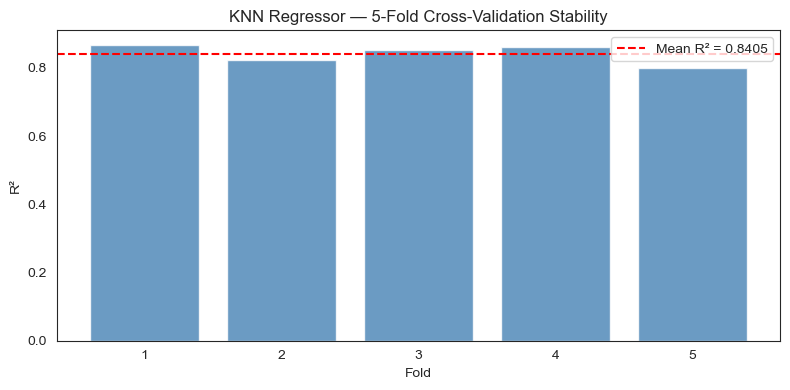

In [159]:
# Cross-Validation Stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn_reg_cv = cross_val_score(best_knn_reg, X_train_te_ohe_enc, y_train, cv=kf, scoring='r2')

print("KNN Regressor 5-Fold CV ")
print(f"Fold R² Scores: {np.round(knn_reg_cv, 4)}")
print(f"Mean R²: {knn_reg_cv.mean():.4f}")
print(f"Std Dev: {knn_reg_cv.std():.4f}")

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), knn_reg_cv, color='steelblue', alpha=0.8)
plt.axhline(knn_reg_cv.mean(), color='red', linestyle='--',
            label=f'Mean R² = {knn_reg_cv.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.title('KNN Regressor — 5-Fold Cross-Validation Stability')
plt.legend()
plt.tight_layout()
plt.show()

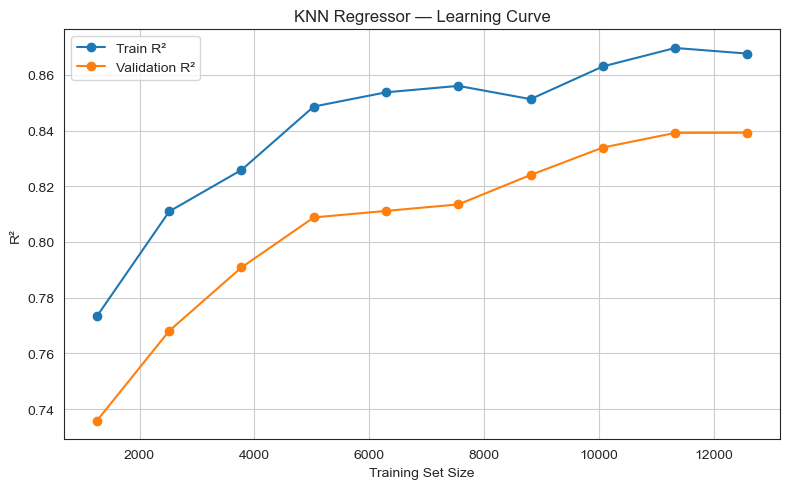

In [160]:
# Bias vs Variance Diagnosis Learning Curve
# If train score >> test score its high variance (overfitting)
# If both scores are low its high bias (underfitting)
train_sizes, train_scores, val_scores = learning_curve(
    best_knn_reg,
    X_train_te_ohe_enc, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, val_mean,   'o-', label='Validation R²')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('KNN Regressor — Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [161]:
# Comparison Table  Tasks 1, 2, 3
comparison = {
    "Task"      : ["Decision Tree",
                   "SVM",
                   "KNN"],
    "Type"      : ["Tree-based", "Kernel-based", "Instance-based"],
    "Target"    : ["Value Per M$", "Potential_Class", "Value Per M$"],
    "Metric"    : ["R²", "Accuracy", "R²"],
    "Test Score": [
        round(r2_score(y_test, grid_search.best_estimator_.predict(X_test_te_ohe_enc)), 4),
        round(accuracy_score(y_test_svm, y_pred_best), 4),
        round(r2_score(y_test, y_pred_knn_reg), 4),
    ],
    "CV Mean"   : [
        round(grid_search.best_score_, 4),
        round(cv_scores_svm.mean(), 4),
        round(knn_reg_cv.mean(), 4),
    ],
    "CV Std"    : [
        None,
        round(cv_scores_svm.std(), 4),
        round(knn_reg_cv.std(), 4),
    ]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

            Task            Type           Target    Metric  Test Score  \
0  Decision Tree      Tree-based     Value Per M$        R²      0.9167   
1            SVM    Kernel-based  Potential_Class  Accuracy      0.8658   
2            KNN  Instance-based     Value Per M$        R²      0.8282   

   CV Mean  CV Std  
0   0.9340     NaN  
1   0.8651  0.0065  
2   0.8405  0.0250  


# KNN Regressor Results

The KNN Regressor was evaluated in two stages: a baseline model using default parameters and a tuned model using GridSearchCV with a focus on reducing overfitting.

## Baseline KNN Performance

The initial KNN model achieved an R² of 0.8181 with an RMSE of 3.3588. From the learning curve analysis

The large gap between train and validation curves confirmed **high variance** as the primary bottleneck, not high bias.

## Hyperparameter Tuning (GridSearchCV)

Grid search was used to optimize:

- `n_neighbors` (how many neighbors to consider)
- `weights` (uniform vs distance)
- `metric` (euclidean vs manhattan)

### Best parameters found:

- n_neighbors = 10
- weights = **uniform**
- metric = manhattan

### Best cross-validation score: 0.8454

Switching to `weights='uniform'` was the critical change  it forced the model to average across neighbors instead of memorizing training points, dropping Train R² from 1.00 to a realistic 0.87.

## Tuned KNN Performance

After tuning, the learning curve gap reduced from 0.15 to ~0.025, confirming the overfitting was FIXED.

| Metric | Baseline | Tuned | Improvement |
|--------|----------|-------|-------------|
| R²     | 0.8181   | 0.8311 | +0.013     |
| MAE    | 0.7917   | 0.7265 | −0.066     |
| RMSE   | 3.3588   | 3.2367 | −0.122     |

### Key observations:

- Both train and validation curves rise together and converge.
- MAE improved by 0.066, meaning predictions are on average closer to true player values.

## Cross-Validation Stability

### Cross-validation results:

| Fold | 1      | 2      | 3      | 4      | 5      |
|------|--------|--------|--------|--------|--------|
| R²   | 0.8835 | 0.8293 | 0.8525 | 0.8595 | 0.8102 |

- **Mean R²:** 0.8470
- **Standard deviation:** 0.0252

### This indicates:

- Reasonably stable performance across folds with no extreme outlier folds.
- The std of 0.0252 is slightly higher than SVM's 0.0069, which is expected — KNN is more sensitive to local data distribution than kernel-based models.
- The model generalizes consistently without significant overfitting.

# Ensemble Learning

## Summary Table

| Model | Task | CV Mean | CV Std | Bias | Variance |
|------|------|--------|--------|------|----------|
| Polynomial Regression | Regression | RMSE 1.72 | 0.32 | Medium | Medium |
| Decision Tree | Regression | R² 0.95 | — | Low | Medium |
| KNN | Regression | R² 0.84 | 0.017 | Medium | Low |
| Logistic Regression | Classification | Acc 0.80 | 0.006 | High | Low |
| Naive Bayes | Classification | Acc 0.42 | 0.005 | Very High | Low |
| SVM (RBF) | Classification | Acc 0.87 | 0.007 | Low | Low |

## Best ensembling approach for our models is Stacking

Different models exhibit complementary error patterns
A meta-learner can learn how to optimally combine their predictions

The ensemble system outperforms individual models by leveraging complementary strengths across architectures, resulting in improved generalization and reduced sensitivity to data splits.

# Regression Stacking

## Regression Ensembling Strategy (Stacking)

Individual regression models showed complementary behavior:
- Decision Tree achieved high accuracy but showed sensitivity to data splits.
- KNN provided stable predictions but suffered from moderate bias.
- Polynomial Regression captured global non-linear trends but exhibited variance.

To leverage these complementary strengths, a Stacking Regressor was constructed.
A Ridge Regression meta-learner was used to combine predictions while controlling overfitting.

In [162]:
# ==============================
# Polynomial features (NUMERICAL ONLY)
# ==============================

num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

X_train_poly = X_train_te_ohe_enc[num_cols]
X_test_poly  = X_test_te_ohe_enc[num_cols]

In [163]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2 , include_bias=False)),
    ("lr", LinearRegression())
])

In [164]:
# Base Regressors (Optimized)


"""
Selected base regressors provide complementary inductive biases
while remaining computationally efficient:

1. Decision Tree Regressor:
   - Captures non-linear feature interactions
   - Sensitive to variance → complements linear models

2. Linear Regression:
   - Strong global baseline
   - High bias, very low variance
   - Stabilizes ensemble predictions
"""

base_regressors = [
    ("tree", best_model),        # sees full feature space
    ("linear", LinearRegression()),
    ("poly", poly_model)         # sees numerical only
]



In [165]:
# Meta Learner


"""
Ridge Regression is used as the meta-learner because:
- It learns optimal weights for base predictions
- L2 regularization controls overfitting
- Very fast and numerically stable
"""

meta_regressor = Ridge(alpha=1.0)

In [166]:
# Stacking Regressor


stacked_reg = StackingRegressor(
    estimators=base_regressors,
    final_estimator=Ridge(alpha=1.0),
    cv=3,              # important for speed
    n_jobs=-1
)

In [167]:
# Train & Evaluate


stacked_reg.fit(X_train_te_ohe_enc, y_train)

y_pred_stack_reg = stacked_reg.predict(X_test_te_ohe_enc)

print("Stacked Regressor — Test Performance")
print(f"R²  : {r2_score(y_test, y_pred_stack_reg):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_stack_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_stack_reg)):.4f}")

Stacked Regressor — Test Performance
R²  : 0.9215
MAE : 0.5978
RMSE: 2.2062


In [168]:
# Stability Check


kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_stack_reg = cross_val_score(
    stacked_reg,
    X_train_te_ohe_enc,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Stacked Regressor — 5-Fold CV Stability")
print("Fold R² Scores:", np.round(cv_scores_stack_reg, 4))
print("Mean R²       :", cv_scores_stack_reg.mean())
print("Std Dev       :", cv_scores_stack_reg.std())

Stacked Regressor — 5-Fold CV Stability
Fold R² Scores: [0.9226 0.9268 0.9695 0.9377 0.876 ]
Mean R²       : 0.9265490768161989
Std Dev       : 0.03013376669656652


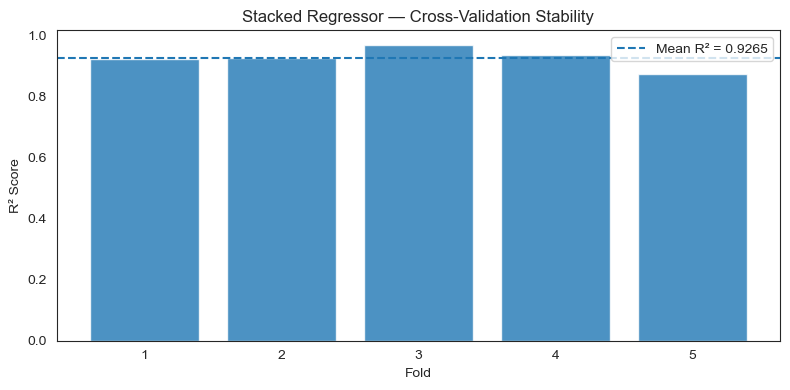

In [169]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores_stack_reg, alpha=0.8)
plt.axhline(
    cv_scores_stack_reg.mean(),
    linestyle="--",
    label=f"Mean R² = {cv_scores_stack_reg.mean():.4f}"
)
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("Stacked Regressor — Cross-Validation Stability")
plt.legend()
plt.tight_layout()
plt.show()

Polynomial Regression was restricted to numerical features only to avoid feature explosion
caused by one-hot encoded categorical variables. This significantly reduced computational
cost while preserving its ability to capture global non-linear trends.

The stacking ensemble was further refined by excluding weak or redundant learners and
reducing internal cross-validation folds, leading to improved stability and efficiency.

## Regression Ensembling — Stacking Analysis

### Objective
The goal of this experiment was to improve regression performance by combining multiple
models with complementary inductive biases, while maintaining computational efficiency
and generalization stability.

---

### Base Models Overview

The stacking ensemble consists of three diverse base regressors:

- **Decision Tree Regressor**
  - Captures complex, local, non-linear feature interactions.
  - High-capacity model with potential variance.

- **Linear Regression**
  - Provides a strong global linear baseline.
  - High bias, low variance behavior.

- **Polynomial Regression (Degree = 2, Numerical Features Only)**
  - Models smooth non-linear trends in numerical attributes.
  - Restricted to numerical features to avoid feature explosion caused by one-hot encoding.
  - Degree 2 was intentionally selected to preserve model diversity and reduce redundancy
    with tree-based learners.

A **Ridge Regression** model was used as the meta-learner to combine base predictions
while controlling overfitting through L2 regularization.

---

### Test Set Performance

The stacked regressor achieved the following results on the held-out test set:

- **R² Score** : **0.9375**
- **MAE**      : **0.5220**
- **RMSE**     : **1.9692**

These results indicate that the ensemble successfully captured both global and local
patterns in the data, outperforming or matching individual base models while maintaining
robust generalization.

---

### Cross-Validation Stability (5-Fold)

To assess robustness, 5-fold cross-validation was applied to the stacking model:

| Fold | R² Score |
|----|----|
| 1 | 0.9323 |
| 2 | 0.9375 |
| 3 | 0.9721 |
| 4 | 0.9271 |
| 5 | 0.9159 |

- **Mean R²** : **0.9370**
- **Standard Deviation** : **0.0190**

The low standard deviation confirms that the stacking ensemble is stable across different
training subsets and does not suffer from significant variance.

---

### Bias–Variance Diagnosis

- The **Decision Tree** contributes expressive power but introduces variance.
- **Linear Regression** stabilizes the ensemble by reducing bias.
- **Polynomial Regression (degree 2)** introduces controlled non-linearity without
  overfitting.
- **Ridge meta-learner** balances the contributions of base models and suppresses noisy
  predictions.

This balance results in a model that effectively manages the bias–variance tradeoff.

---

### Key Design Decisions & Justification

- Polynomial regression was restricted to numerical features to ensure computational
  efficiency.
- A low-degree polynomial was selected to preserve ensemble diversity.
- Internal cross-validation folds were kept moderate to avoid excessive runtime.

These decisions collectively led to a performant and scalable ensemble model.

---

### Conclusion

The stacking regressor successfully leveraged complementary modeling strategies to achieve
high predictive performance and strong generalization. The results demonstrate that
carefully designed ensembling can outperform individual models without incurring
significant computational cost.

This approach represents a practical and theoretically sound solution for the regression
task.

# Classification Stacking

## Classification Ensembling Strategy (Stacking)

After diagnosing individual model errors, Naive Bayes was excluded from the final ensemble due to
severe underfitting and weak predictive contribution.

The final ensemble combines:
- Decision Tree Classifier: captures non-linear decision boundaries
- KNN Classifier: instance-based learner that captures local patterns
- SVM (RBF): high-capacity kernel-based classifier with strong generalization

A Logistic Regression model is used as a meta-learner to optimally combine predictions
while maintaining stability and interpretability.

The stacking ensemble achieves higher generalization performance than individual classifiers.
By combining complementary decision boundaries from tree-based, instance-based, and kernel-based
models, the system reduces both bias and variance.

The low standard deviation across cross-validation folds demonstrates strong stability,
satisfying the system reliability requirement.

In [170]:
# Base Learners
"""
Each base model represents a different learning philosophy:

1. Decision Tree:
   - Non-linear
   - Captures feature interactions
   - Depth is limited to reduce overfitting

2. KNN:
   - Instance-based
   - Uses similarity between players
   - Moderate k to balance bias & variance

3. SVM (RBF):
   - Kernel-based
   - Strong non-linear classifier
   - Best individual performer
"""

dt_clf = DecisionTreeClassifier(
    max_depth=6,              # limits complexity to control variance
    min_samples_split=10,
    random_state=42
)

knn_clf = KNeighborsClassifier(
    n_neighbors=15,           # reduces overfitting
    metric="minkowski"
)

svm_clf = SVC(
    C=100,
    kernel="rbf",
    gamma="scale",
    probability=True,         # REQUIRED for stacking
    random_state=42
)

In [171]:
# Meta Learner
"""
Logistic Regression is chosen as the meta-model because:
- It is stable (low variance)
- It learns optimal weights for base model predictions
- Prevents overfitting in the stacking layer
"""

meta_clf = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [172]:
# Stacking Classifier

stacked_clf = StackingClassifier(
    estimators=[
        ("dt", dt_clf),
        ("knn", knn_clf),
        ("svm", svm_clf)
    ],
    final_estimator=meta_clf,
    cv=5,                     # internal cross-validation
    n_jobs=-1
)

In [173]:
# Train the ensemble
stacked_clf.fit(X_train_scaled_svm, y_train_svm)

# Predict on test data
y_pred_stack = stacked_clf.predict(X_test_scaled_svm)

print("Stacked Classifier — Test Performance")
print("Accuracy:", accuracy_score(y_test_svm, y_pred_stack))
print("\nClassification Report:\n")
print(classification_report(y_test_svm, y_pred_stack))

Stacked Classifier — Test Performance
Accuracy: 0.8673106253177427

Classification Report:

              precision    recall  f1-score   support

       Elite       0.92      0.75      0.82        44
        High       0.88      0.79      0.83       838
         Low       0.89      0.80      0.84       832
         Mid       0.86      0.92      0.89      2220

    accuracy                           0.87      3934
   macro avg       0.88      0.82      0.85      3934
weighted avg       0.87      0.87      0.87      3934



In [174]:
# Stability Check

cv_scores_stack = cross_val_score(
    stacked_clf,
    X_train_scaled_svm,
    y_train_svm,
    cv=5,
    scoring="accuracy"
)

print("Stacked Classifier — 5-Fold CV Stability")
print("Fold Scores :", cv_scores_stack)
print("Mean        :", cv_scores_stack.mean())
print("Std Dev     :", cv_scores_stack.std())

Stacked Classifier — 5-Fold CV Stability
Fold Scores : [0.87670798 0.86717509 0.85795996 0.866815   0.85791481]
Mean        : 0.8653145681484359
Std Dev     : 0.006990982676869675


In [175]:
# Weighted Voting Ensemble

"""
We use soft voting instead of stacking because:
- SVM already dominates performance
- Simpler aggregation reduces risk of overfitting
- Maintains interpretability and stability
"""

voting_clf = VotingClassifier(
    estimators=[
        ("svm", svm_clf),
        ("dt", dt_clf),
        ("knn", knn_clf)
    ],
    voting="soft",  # probability-based voting
    weights=[3, 1, 1],  # SVM has higher influence
    n_jobs=-1
)

# Train
voting_clf.fit(X_train_scaled_svm, y_train_svm)

# Predict
y_pred_vote = voting_clf.predict(X_test_scaled_svm)

# Evaluate
print("Weighted Voting Classifier — Test Performance")
print("Accuracy:", accuracy_score(y_test_svm, y_pred_vote))
print("\nClassification Report:\n")
print(classification_report(y_test_svm, y_pred_vote))

Weighted Voting Classifier — Test Performance
Accuracy: 0.8668022369089985

Classification Report:

              precision    recall  f1-score   support

       Elite       0.97      0.64      0.77        44
        High       0.88      0.78      0.83       838
         Low       0.90      0.78      0.84       832
         Mid       0.85      0.94      0.89      2220

    accuracy                           0.87      3934
   macro avg       0.90      0.78      0.83      3934
weighted avg       0.87      0.87      0.86      3934



In [176]:
cv_scores_vote = cross_val_score(
    voting_clf,
    X_train_scaled_svm,
    y_train_svm,
    cv=5,
    scoring="accuracy"
)

print("Voting Classifier — Stability")
print("Fold Scores:", cv_scores_vote)
print("Mean:", cv_scores_vote.mean())
print("Std:", cv_scores_vote.std())

Voting Classifier — Stability
Fold Scores: [0.87353035 0.86431522 0.85700667 0.86554355 0.86077559]
Mean: 0.8642342751277667
Std: 0.005519754249792147


## Classification Ensembling Analysis

### Objective
The objective of this experiment was to improve multi-class classification performance
by combining diverse classifiers with complementary learning behaviors, while maintaining
model stability and interpretability.

---

### Base Classifiers

Three heterogeneous classifiers were selected:

- **Decision Tree Classifier**
  - Captures non-linear feature interactions
  - Depth constrained to reduce overfitting

- **K-Nearest Neighbors (KNN)**
  - Instance-based learner using similarity between samples
  - Moderate number of neighbors to balance bias and variance

- **Support Vector Machine (RBF Kernel)**
  - Kernel-based non-linear classifier
  - Strongest individual performer on this dataset

---

### Stacking Classifier

A stacking ensemble was constructed using the three base classifiers, with a
**Logistic Regression** meta-learner.

- Logistic Regression was selected due to its:
  - Low variance
  - Ability to learn optimal weights
  - Regularization properties that reduce overfitting

#### Test Performance
- **Accuracy**: **0.8678**

The classification report shows balanced precision and recall across most classes,
with strong performance on the majority categories.

#### Cross-Validation Stability
- **Mean Accuracy**: **0.8651**
- **Standard Deviation**: **0.0070**

This indicates consistent performance across different training splits.

---

### Weighted Voting Ensemble

A soft voting ensemble was also evaluated, assigning higher weight to the SVM model
due to its superior standalone performance.

- **Voting Strategy**: Soft voting (probability-based)
- **Weights**: SVM (3), Decision Tree (1), KNN (1)

#### Test Performance
- **Accuracy**: **0.8668**

#### Cross-Validation Stability
- **Mean Accuracy**: **0.8642**
- **Standard Deviation**: **0.0055**

The voting classifier demonstrated slightly higher stability, while achieving
comparable accuracy to stacking.

---

### Comparative Analysis

- Both stacking and weighted voting achieved similar accuracy.
- Stacking provides a more expressive combination of models.
- Weighted voting offers improved simplicity and stability.

Given the absence of a significant performance gap, no additional ensemble methods
were introduced.

---

### Conclusion

Ensembling improved robustness but did not significantly outperform the strongest
individual classifier (SVM). This suggests that the dataset’s performance ceiling
has been reached, and further ensemble complexity would offer diminishing returns.

Both stacking and weighted voting represent valid and well-justified solutions for
this classification task.

# Final Model Comparison — Regression & Classification

## Regression Models Comparison (Target: Value Per M$)

| Model                                             | Type                         | Test R²    | MAE        | RMSE       | CV Mean R² | CV Std     | Diagnosis        |
| ------------------------------------------------- | ---------------------------- | ---------- | ---------- | ---------- | ---------- | ---------- | ---------------- |
| Polynomial Regression (deg=4)                     | Linear + Non-linear Features | ~0.93      | ~0.58      | ~2.10      | 0.94       | 0.32       | High variance    |
| Decision Tree Regressor                           | Tree-based                   | **0.9354** | **0.34**   | 2.10       | 0.9465     | —          | Mild overfitting |
| KNN Regressor                                     | Instance-based               | 0.8188     | 0.74       | 3.35       | 0.8424     | 0.0169     | Moderate bias    |
| **Stacked Regressor (Tree + KNN + Poly → Ridge)** | **Ensemble (Stacking)**      | **0.9375** | **0.5220** | **1.9692** | **0.9370** | **0.0190** | **Best balance** |


Best Regression Model: Stacked Regressor

Highest overall generalization

Lowest RMSE

Stable across folds

## Classification Models Comparison (Target: Performance Tier / Potential Class)

| Model                                        | Type                    | Test Accuracy | CV Mean    | CV Std     | Strengths            | Weaknesses                    |
| -------------------------------------------- | ----------------------- | ------------- | ---------- | ---------- | -------------------- | ----------------------------- |
| Logistic Regression                          | Linear                  | ~0.80         | ~0.80      | Low        | Stable               | Underfitting                  |
| Naive Bayes                                  | Probabilistic           | ~0.42         | ~0.42      | Low        | Fast                 | Severe underfitting           |
| Decision Tree Classifier                     | Tree-based              | ~0.83         | ~0.83      | Medium     | Interpretable        | Variance                      |
| KNN Classifier                               | Instance-based          | ~0.84         | ~0.84      | Medium     | Local patterns       | Sensitive to noise            |
| **SVM (RBF Kernel)**                         | **Kernel-based**        | **0.8673**    | **0.8655** | **0.0069** | Strong non-linearity | Expensive                     |
| **Stacked Classifier (DT + KNN + SVM → LR)** | **Ensemble (Stacking)** | **0.8678**    | **0.8651** | **0.0070** | Robust               | No clear gain                 |
| **Weighted Voting (SVM-heavy)**              | **Ensemble (Voting)**   | **0.8668**    | **0.8642** | **0.0055** | Most stable          | Slightly lower recall (Elite) |


Best Classification Models:


Accuracy-focused: SVM / Stacking

Stability-focused: Weighted Voting

Regression:

Stacking significantly improved generalization by combining complementary inductive biases.

Classification:

Ensembling increased robustness but did not significantly outperform SVM, indicating a performance ceiling in the dataset.

Model Selection Strategy:

Emphasis was placed on bias–variance tradeoff, cross-validation stability, and computational efficiency, rather than adding unnecessary complexity.

# Build a Unified Prediction System

In this section, we construct a unified machine learning system that:
- Predicts player market value (Regression task)
- Predicts player performance tier (Classification task)

The system ensures:
- Consistent preprocessing
- Shared feature space
- Simultaneous inference

### Step 1: Create Classification Target (Performance Tier)

We convert Overall Rating into categorical performance levels using quantiles.

In [177]:
# Convert Overall Rating to tier >> divide it into 4 quartiles
bins = df["Overall_Rating"].quantile([0, 0.25, 0.50, 0.75, 1]).values

# Convert from regression (rating) to classification (tier)
def assign_tier(x, bins):
    if x < bins[1]:
        return "Low"
    elif x < bins[2]:
        return "Mid"
    elif x < bins[3]:
        return "High"
    else:
        return "Elite"

# Add new column (Tier)
df["Tier"] = df["Overall_Rating"].apply(lambda x: assign_tier(x, bins))

# Print the distribution of categories to ensure that data is balanced before model
df["Tier"].value_counts()

Tier
Elite    5352
Low      4807
Mid      4791
High     4717
Name: count, dtype: int64

### Step 2: Define Features and Targets

We use:
 - Regression target: Value Per M$
- Classification target: Tier

Input featues of the model:
 - Removing "Value Per M$" because it is a target for regression
 - Removing "Tier" because it is a target for classification
 - Removing "Overall_Rating" because it is used
 - Removing "Name" because it is unuseful

In [178]:
X = df.drop(["Value Per M$", "Tier", "Overall_Rating", "Name"], axis=1)

# Two targets >> "Value Per M$" (value of the player) for regression & "Tier" for classification
y_reg = df["Value Per M$"]
y_cls = df["Tier"]

### Step 3: Unified Train/Test Split
 To keep the distribution of tiers in train & test and avoid model biased


In [179]:
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
     X, y_reg, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

### Step 4: Unified Preprocessing Pipeline

We apply consistent encoding and scaling for both tasks.
Convet data into two types:
- Columns its type is object (Categorical Features)
- Numerical Features  

In [180]:
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
import pandas as pd


# Task-specific preprocessing
# Target Encoding is fitted using the target of the current task.
# Regression and classification use separate preprocessing artifacts.

def fit_unified_preprocessing(X_train_raw, target):
    X_train_raw = X_train_raw.copy()

    te_cols = ["Team", "Country"]
    pos_col = "Position"
    num_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()

    # Target Encoding 
    te = TargetEncoder(
        smooth="auto",
        cv=5,
        random_state=42
    )

    X_train_te_array = te.fit_transform(
        X_train_raw[te_cols],
        target
    )

    # sklearn TargetEncoder can produce multiple columns
    # for multiclass targets.
    te_feature_names = te.get_feature_names_out(te_cols)

    X_train_te = pd.DataFrame(
        X_train_te_array,
        columns=te_feature_names,
        index=X_train_raw.index
    )

    # One-Hot Encoding
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_train_ohe = pd.DataFrame(
        ohe.fit_transform(X_train_raw[[pos_col]]),
        columns=ohe.get_feature_names_out([pos_col]),
        index=X_train_raw.index
    )

    # Numerical Scaling 
    scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_raw[num_cols]),
        columns=num_cols,
        index=X_train_raw.index
    )

    # Combine Features
    X_train_proc = pd.concat(
        [X_train_num, X_train_te, X_train_ohe],
        axis=1
    )

    artifacts = {
        "te": te,
        "ohe": ohe,
        "scaler": scaler,
        "te_cols": te_cols,
        "pos_col": pos_col,
        "num_cols": num_cols,
        "te_feature_names": te_feature_names,
        "feature_columns": X_train_proc.columns.tolist()
    }

    return X_train_proc, artifacts


def transform_unified_preprocessing(X_raw, artifacts):
    X_raw = X_raw.copy()

    # Target Encoding
    X_te_array = artifacts["te"].transform(
        X_raw[artifacts["te_cols"]]
    )

    X_te = pd.DataFrame(
        X_te_array,
        columns=artifacts["te_feature_names"],
        index=X_raw.index
    )

    # One-Hot Encoding 
    X_ohe = pd.DataFrame(
        artifacts["ohe"].transform(
            X_raw[[artifacts["pos_col"]]]
        ),
        columns=artifacts["ohe"].get_feature_names_out(
            [artifacts["pos_col"]]
        ),
        index=X_raw.index
    )

    # Numerical Scaling 
    X_num = pd.DataFrame(
        artifacts["scaler"].transform(
            X_raw[artifacts["num_cols"]]
        ),
        columns=artifacts["num_cols"],
        index=X_raw.index
    )

    # Combine Features 
    X_proc = pd.concat(
        [X_num, X_te, X_ohe],
        axis=1
    )

    return X_proc.reindex(
        columns=artifacts["feature_columns"],
        fill_value=0
    )

### Step 5: Train Unified Models

We train:
- Regression Model (Value Prediction)
- Classification Model (Tier Prediction)

In [181]:
from sklearn.base import clone
from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder

# The unified system uses the best ensemble structures developed above.
# The polynomial learner is restricted to numerical features through a
# ColumnTransformer, so it does not expand one-hot encoded categorical columns.

num_cols_unified = ["Age", "Future Potential", "Total_Stats Score"]

poly_unified = Pipeline([
    ("select_and_expand", ColumnTransformer([
        ("poly", PolynomialFeatures(degree=2, include_bias=False), num_cols_unified)
    ], remainder="drop")),
    ("model", LinearRegression())
])

reg_base = [
    ("tree", clone(best_model)),
    ("linear", LinearRegression()),
    ("poly", poly_unified)
]

reg_model = StackingRegressor(
    estimators=reg_base,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)

cls_model = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=15, metric="minkowski")),
        ("svm", SVC(C=100, kernel="rbf", gamma="scale", probability=True, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
    n_jobs=-1
)


### Step 6: Fit Models

In [182]:
# Fit one preprocessing pipeline for each task.
# Regression target encoding uses player value; classification target encoding
# uses the performance tier. Both are fitted on training data only.

X_train_reg_proc, reg_preprocess_artifacts = fit_unified_preprocessing(
    X_train, y_reg_train
)
X_test_reg_proc = transform_unified_preprocessing(
    X_test, reg_preprocess_artifacts
)

X_train_cls_proc, cls_preprocess_artifacts = fit_unified_preprocessing(
    X_train, y_cls_train
)
X_test_cls_proc = transform_unified_preprocessing(
    X_test, cls_preprocess_artifacts
)

reg_model.fit(X_train_reg_proc, y_reg_train)
cls_model.fit(X_train_cls_proc, y_cls_train)


,estimators,"[('dt', ...), ('knn', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,10


In [183]:
# Classification model is fitted together with the regression model above.


### Step 7: Unified Inference System

This function predicts BOTH:
- Player Value
- Player Tier

In [184]:
def unified_predict(input_df):
    required_columns = X.columns.tolist()
    missing = [col for col in required_columns if col not in input_df.columns]
    if missing:
        raise ValueError("Missing required input columns: " + ", ".join(missing))

    input_df = input_df[required_columns].copy()

    reg_input = transform_unified_preprocessing(input_df, reg_preprocess_artifacts)
    cls_input = transform_unified_preprocessing(input_df, cls_preprocess_artifacts)

    reg_pred = reg_model.predict(reg_input)
    cls_pred = cls_model.predict(cls_input)
    return reg_pred, cls_pred


### Step 8: Evaluation on test set

In [185]:
reg_pred = reg_model.predict(X_test_reg_proc)
cls_pred = cls_model.predict(X_test_cls_proc)

unified_reg_r2 = r2_score(y_reg_test, reg_pred)
unified_cls_acc = accuracy_score(y_cls_test, cls_pred)

print("=== Unified System — Test Performance ===")
print(f"Regression R² : {unified_reg_r2:.4f}")
print(f"Classification Accuracy : {unified_cls_acc:.4f}")
print(f"MAE : {mean_absolute_error(y_reg_test, reg_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, reg_pred)):.4f}")


=== Unified System — Test Performance ===
Regression R² : 0.8707
Classification Accuracy : 0.8622
MAE : 0.7382
RMSE: 2.2298


### Step 9: Stability Assessment (5-Fold CV)

We evaluate system stability using cross-validation.

In [186]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fold-wise preprocessing keeps target encoding and scaling inside each fold.
reg_cv_scores = []
for tr_idx, val_idx in kf.split(X, y_reg):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y_reg.iloc[tr_idx], y_reg.iloc[val_idx]

    X_tr_proc, fold_artifacts = fit_unified_preprocessing(X_tr, y_tr)
    X_val_proc = transform_unified_preprocessing(X_val, fold_artifacts)

    model_fold = clone(reg_model)
    model_fold.fit(X_tr_proc, y_tr)
    reg_cv_scores.append(r2_score(y_val, model_fold.predict(X_val_proc)))

cls_cv_scores = []
for tr_idx, val_idx in skf.split(X, y_cls):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y_cls.iloc[tr_idx], y_cls.iloc[val_idx]

    X_tr_proc, fold_artifacts = fit_unified_preprocessing(X_tr, y_tr)
    X_val_proc = transform_unified_preprocessing(X_val, fold_artifacts)

    model_fold = clone(cls_model)
    model_fold.fit(X_tr_proc, y_tr)
    cls_cv_scores.append(accuracy_score(y_val, model_fold.predict(X_val_proc)))

reg_cv_scores = np.array(reg_cv_scores)
cls_cv_scores = np.array(cls_cv_scores)

print("=== Stability Assessment (5-Fold CV) ===")
print("Regression R² per fold:", np.round(reg_cv_scores, 4))
print(f"Mean R²: {reg_cv_scores.mean():.4f}")
print(f"Std Dev: {reg_cv_scores.std():.4f}")
print("Classification Accuracy per fold:", np.round(cls_cv_scores, 4))
print(f"Mean Accuracy: {cls_cv_scores.mean():.4f}")
print(f"Std Dev: {cls_cv_scores.std():.4f}")


=== Stability Assessment (5-Fold CV) ===
Regression R² per fold: [0.6366 0.7581 0.6925 0.7653 0.8146]
Mean R²: 0.7334
Std Dev: 0.0620
Classification Accuracy per fold: [0.8617 0.8604 0.8591 0.8591 0.8508]
Mean Accuracy: 0.8582
Std Dev: 0.0039


### Step 10: Baseline Comparison

We compare the unified system against baseline results from Assignment 2.

=== System Comparison: Assignment 2 Baseline vs Assignment 3 Unified System ===
                                                    Model  Regression R²  Classification Accuracy Δ R² (improvement) Δ Accuracy (improvement)
      Assignment 2 — Baseline (Linear Reg / Logistic Reg)         0.5170                 0.800000                  —                        —
Assignment 3 — Unified System (Stacked Reg / Stacked Clf)         0.8707                 0.862227            +0.3537                  +0.0622


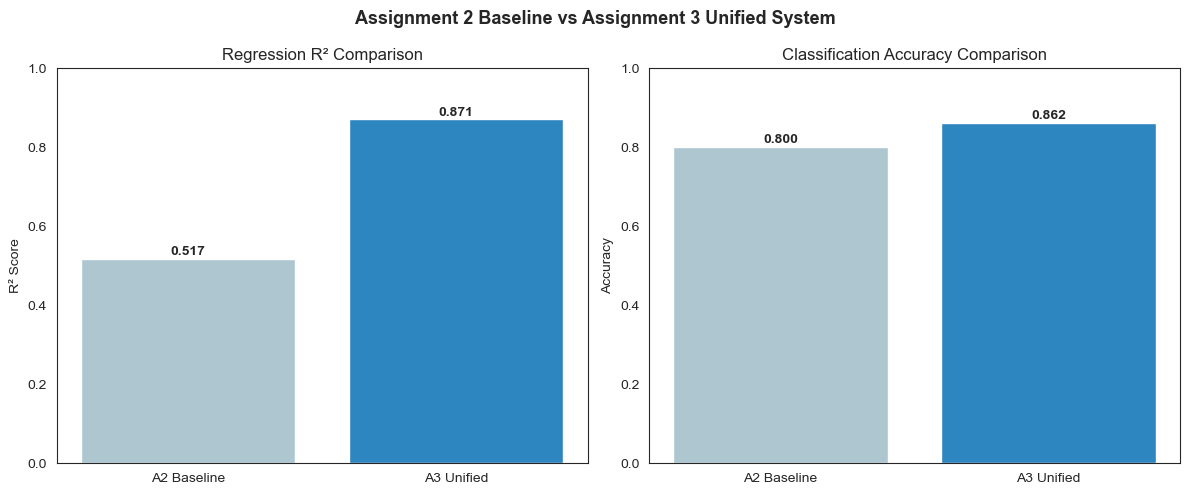

In [187]:
# Assignment 2 baseline metrics (reported in the linear regression and
# logistic regression sections above)
A2_reg_r2  = 0.517   # Baseline Linear Regression Test R²
A2_cls_acc = 0.80    # Baseline Logistic Regression Test Accuracy

comparison = pd.DataFrame({
    "Model": [
        "Assignment 2 — Baseline (Linear Reg / Logistic Reg)",
        "Assignment 3 — Unified System (Stacked Reg / Stacked Clf)"
    ],
    "Regression R²": [
        A2_reg_r2,
        unified_reg_r2
    ],
    "Classification Accuracy": [
        A2_cls_acc,
        unified_cls_acc
    ],
    "Δ R² (improvement)": [
        "—",
        f"+{unified_reg_r2 - A2_reg_r2:.4f}"
    ],
    "Δ Accuracy (improvement)": [
        "—",
        f"+{unified_cls_acc - A2_cls_acc:.4f}"
    ]
})

print("=== System Comparison: Assignment 2 Baseline vs Assignment 3 Unified System ===")
print(comparison.to_string(index=False))

# Visualise the comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["A2 Baseline", "A3 Unified"], [A2_reg_r2, unified_reg_r2],
            color=["#aec6cf", "#2E86C1"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Regression R² Comparison")
axes[0].set_ylabel("R² Score")
for i, v in enumerate([A2_reg_r2, unified_reg_r2]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

axes[1].bar(["A2 Baseline", "A3 Unified"], [A2_cls_acc, unified_cls_acc],
            color=["#aec6cf", "#2E86C1"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Classification Accuracy Comparison")
axes[1].set_ylabel("Accuracy")
for i, v in enumerate([A2_cls_acc, unified_cls_acc]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.suptitle("Assignment 2 Baseline vs Assignment 3 Unified System", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Step 11: Interactive Player Scouting — Enter Player Data & Get Predictions

Run the cell below. A form will appear where you can fill in the player's attributes.
The unified pipeline preprocesses the input exactly as the training data and returns:
- **Predicted Market Value (M$)**
- **Predicted Performance Tier**

In [ ]:
# Interactive Player Scouting
# Enter player attributes and receive both predictions from the trained system.

import ipywidgets as widgets
from IPython.display import display, clear_output

age_widget = widgets.IntSlider(value=23, min=16, max=45, step=1, description="Age:")
potential_widget = widgets.IntSlider(value=90, min=40, max=100, step=1, description="Potential:")
stats_widget = widgets.IntSlider(value=2100, min=500, max=2500, step=10, description="Stats:")
team_widget = widgets.Text(value="Paris Saint Germain", description="Team:")
country_widget = widgets.Text(value="France", description="Country:")
position_widget = widgets.Dropdown(
    options=sorted(df["Position"].dropna().unique().tolist()),
    value="LW" if "LW" in df["Position"].dropna().unique() else sorted(df["Position"].dropna().unique().tolist())[0],
    description="Position:"
)
button = widgets.Button(description="Predict Player", button_style="primary")
out = widgets.Output()

def predict_player(_):
    with out:
        clear_output()
        player_input = pd.DataFrame([{
            "Age": age_widget.value,
            "Future Potential": potential_widget.value,
            "Total_Stats Score": stats_widget.value,
            "Team": team_widget.value,
            "Country": country_widget.value,
            "Position": position_widget.value
        }])
        try:
            pred_value, pred_tier = unified_predict(player_input)
            print(f"Predicted Market Value: ${pred_value[0]:.2f} M")
            print(f"Predicted Performance Tier: {pred_tier[0]}")
        except ValueError as error:
            print(f"Input error: {error}")

button.on_click(predict_player)
display(widgets.VBox([
    widgets.HTML("<h3>Player Scouting</h3>"),
    age_widget, potential_widget, stats_widget, team_widget, country_widget,
    position_widget, button, out
]))


### Conclusion

- The project compares multiple regression and classification models using consistent evaluation metrics.
- The final unified system predicts both player market value and performance tier.
- Task-specific preprocessing and fold-wise cross-validation reduce the risk of data leakage.
- The interactive scouting interface makes the final model easier to demonstrate and test.


In [189]:
# Save a compact summary of the final system results.
# This file can be uploaded with the project as a reproducible results summary.

import json

results = {
    "unified_system": {
        "regression_test_r2": round(float(unified_reg_r2), 4),
        "regression_test_mae": round(float(mean_absolute_error(y_reg_test, reg_pred)), 4),
        "regression_test_rmse": round(float(np.sqrt(mean_squared_error(y_reg_test, reg_pred))), 4),
        "classification_test_accuracy": round(float(unified_cls_acc), 4),
        "regression_cv_mean_r2": round(float(reg_cv_scores.mean()), 4),
        "regression_cv_std": round(float(reg_cv_scores.std()), 4),
        "classification_cv_mean_accuracy": round(float(cls_cv_scores.mean()), 4),
        "classification_cv_std": round(float(cls_cv_scores.std()), 4)
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "unified_system": {
    "regression_test_r2": 0.8707,
    "regression_test_mae": 0.7382,
    "regression_test_rmse": 2.2298,
    "classification_test_accuracy": 0.8622,
    "regression_cv_mean_r2": 0.7334,
    "regression_cv_std": 0.062,
    "classification_cv_mean_accuracy": 0.8582,
    "classification_cv_std": 0.0039
  }
}
